In [1]:
import sys
sys.path.append("..")
%load_ext autoreload
%autoreload 2

In [2]:
from IPython.display import Markdown, display

## Testing connection to gemini API

In [98]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    project="saferfood-488120",
    location="northamerica-northeast1",
)

print(llm.invoke("Say hello").content)

KeyboardInterrupt: 

## Testing explanations module

In [ ]:
from interface import explanations

In [ ]:
exp = explanations.risk_explanation(['Salmonella', 'Listeria'], max_output_tokens=2000)

KeyboardInterrupt: 

In [ ]:
len(exp)

1887

In [ ]:
display(Markdown(exp))

Here is information regarding the microorganisms detected in your food:

### Salmonella
Eating food contaminated with Salmonella can lead to salmonellosis, a common type of food poisoning. This infection primarily affects your intestines, causing uncomfortable gastrointestinal symptoms. While most healthy individuals recover, severe cases can lead to dehydration and, if the bacteria spread to the bloodstream, can become life-threatening.

Young children, older adults, and individuals with weakened immune systems are at a much higher risk for severe illness, including more serious infections that can spread beyond the gut.

Symptoms typically begin 6 hours to 6 days after consuming contaminated food. Look out for diarrhea (which may be bloody), fever, and stomach cramps. Nausea and vomiting can also occur. These symptoms usually last for 4 to 7 days.

### Listeria
Consuming food contaminated with Listeria monocytogenes can cause listeriosis, a serious infection. While healthy people might experience mild, flu-like symptoms, listeriosis can lead to severe, invasive illness, including meningitis (inflammation of the brain and spinal cord) or septicemia (blood poisoning), which can be fatal.

Pregnant women, newborns, older adults, and people with weakened immune systems are at significantly higher risk for severe illness. For pregnant women, listeriosis can cause miscarriage, stillbirth, premature delivery, or life-threatening infection in the newborn.

Symptoms can appear anywhere from a few days to several weeks (up to 70 days) after eating contaminated food. For healthy individuals, symptoms might include fever, muscle aches, nausea, or diarrhea. In more severe cases, especially for sensitive populations, symptoms can include headache, stiff neck, confusion, loss of balance, and convulsions, indicating a more serious infection of the brain or bloodstream.

# Testing decision based on bacterial growth

In [ ]:

MICROORGANISM = {
    'lm': {
        'usual_name': 'Listeria monocytogenes',
        'initial': -1.4,
        'raw': 4,
        'medium': 4,
        'fried': 4
    },
    'ss': {
        'usual_name': 'Salmonella enterica',
        'initial': -1.4,
        'raw': 1,
        'medium': 1,
        'fried': 1
    },
    'ec': {
        'usual_name': 'Escherichia coli',
        'initial': -3,
        'raw': -2,
        'medium': -2,
        'fried': -2
    },
    'ta': {
        'usual_name': 'Total bacteria (aerobic mesophilic)',
        'initial': 4,
        'raw': 7,
        'medium': 8,
        'fried': 9
    }
}

In [ ]:
logC = 10
bacterias = [
    data['usual_name']
    for data in MICROORGANISM.values()
    if logC >= data['raw']
]
print(f'{bacterias=}')

bacterias=['Listeria monocytogenes', 'Salmonella enterica', 'Escherichia coli', 'Total bacteria (aerobic mesophilic)']


# Baseline model training

# Developping baseline model pipeline

## Strategy
- First, we want to run all sequences through the primary model (provide [t] and [logCs]) to extract, each time, the parameters of the primary model. Ideally, everything would be assembled into a table where, for each ResponseID or ComBaseID (sequence number), we have as columns: temperature (and/or pH, aW, etc.), and the values of the model parameters for that sequence.
- Next, we pass the table through the secondary model to obtain, for each parameter of the primary model, the parameters of a secondary model as a function of temperature, pH, etc.
- Ultimately, for each parameter of the primary model, we want a secondary model fitted to our training data, which can later be used to predict the primary model parameters as a function of temperature, pH, aW, etc. These will then be used to predict microbial growth over time using a primary model.

So we need to have the _n_ sequences one by one in order to train the _n_ different primary models, where _n_ = `unique(responseID)`



## Imports from Martine notebook (safer-food.ipynb)

In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [84]:
def import_data():
    conditions = pd.read_csv('../raw_data/Conditions.txt', sep='\t')
    experiment_conditions = pd.read_csv('../raw_data/ExperimentConditions.txt', sep='\t')
    experiments = pd.read_csv('../raw_data/Experiments.txt', sep='\t', encoding='latin1')
    logcs = pd.read_csv('../raw_data/LogCs.txt', sep='\t')
    properties = pd.read_csv('../raw_data/Properties.txt', sep='\t')
    response_properties = pd.read_csv('../raw_data/ResponseProperties.txt', sep='\t')
    responses = pd.read_csv('../raw_data/Responses.txt', sep='\t', encoding='latin1')
    source = pd.read_csv('../raw_data/Source.txt', sep='\t')

    return conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source

In [85]:
def merge_data(conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source):
    # Pivot ExperimentConditions table to have one row per ExperimentID before the merge
    # This table is not needed for the actual project, but will be useful for us
    # in the future...
    # experiment_conditions_pivot = experiment_conditions.pivot_table(index='ExperimentID', columns='ConditionID', values='Value').reset_index()

    # Merge the tables to create a single DataFrame for analysis. Will join data based on the logcs table
    data = responses.merge(experiments, left_on='ExperimentID', right_on='ID',
                           how='left'
                           ).drop(columns=['ID_y']
                                  ).rename(columns={'ID_x': 'ResponseID'})
    # data = data.merge(experiment_conditions_pivot, on='ExperimentID', how='left')
    data = data.merge(response_properties, on='ResponseID', how='left'
                      ).rename(columns={'Value_x': 'ResponseValue',
                                        'Value_y': 'ResponsePropertiesValue'})
    data = data.merge(logcs, on='ResponseID', how='right')

    return data

### Statistics on original database

In [91]:
conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source = import_data()
raw_data = merge_data(conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source)

In [93]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484896 entries, 0 to 484895
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ResponseID             484896 non-null  int64  
 1   ExperimentID           481571 non-null  float64
 2   Spec_rate              211925 non-null  float64
 3   RateMethod             0 non-null       float64
 4   MethodID               481162 non-null  object 
 5   OrganismID             481571 non-null  object 
 6   OrganismSpecification  348740 non-null  object 
 7   Comment                72787 non-null   object 
 8   Logc0                  1058 non-null    float64
 9   LogcVar                481504 non-null  float64
 10  TObs                   481571 non-null  float64
 11  Assumed                241191 non-null  object 
 12  SourceID               355056 non-null  float64
 13  MatrixID               355056 non-null  object 
 14  In_on                  355056 non-nu

In [98]:
print(f"{len(raw_data)} data points, {len(raw_data['ResponseID'].unique())} sequences, {len(raw_data['OrganismID'].unique())} microorganisms, {len(raw_data['In_on'].unique())} different food matrices, {len(raw_data['MatrixID'].unique())} food categories, {len(raw_data['PropertyID'].unique())} different propertiesID")

484896 data points, 43429 sequences, 46 microorganisms, 663 different food matrices, 21 food categories, 20 different propertiesID


474

In [6]:
def clean_data(df, min_time_threshold=5, max_time_threshold=504, min_temp_threshold=0, max_temp_threshold=30):
    # Remove data points where the maximum time exceeds a certain treshold
    df = df[(df['TObs'] >= min_time_threshold) & (df['TObs'] <= max_time_threshold)]

    # Remove data points where the temperature is outside a certain treshold
    df = df[(df['Temperature'] >= min_temp_threshold) & (df['Temperature'] <= max_temp_threshold)]

    # Keep data from specific matrices only
    food_matrices = ['beef', 'poultry', 'produce', 'seafood', 'pork']
    df = df[df['MatrixID'].isin(food_matrices)].reset_index()

    # Fill missing values in the DataFrame based on the provided fill_values
    # dictionary
    fill_values = {
        #'n2': 78.1,         # Must calculate the O2 and CO2 value too...
        'Temperature': 21,
        #'pH':,              # Use mean value from the in_on group
        #'Aw':,              # Use mean value from the in_on group
        #'pressure': 0.101325,
        #'acetic_acid':0,
        #'alta':0,
        #'apple_polyphenol':0,
        #'ascorbic_acid':0,
        #'benzoic_acid':0,
        #'betaine':0,
        #'calcium_propionate':0,
        #'carvacrol':0,
        #'chitosan':0,
        #'cinnamaldehyde':0,
        #'citric_acid':0,
        #'clo2':0,
        #'co2':0.04,         # Must calculate the O2 and N2 value too...
        #'dextrose':0,
        #'diacetic_acid':0,
        #'edta':0,
        #'erythorbate':0,
        #'ethanol':0,
        #'fat':,             # Use mean value from the in_on group or drop
        #'fructose':0,
        #'garlic':0,
        #'glucose':0,
        #'glycerol':0,
        #'green_tea_leaf':0,
        #'green_tea_polyphenol':0,
        #'hcl':0,
        #'irradiated':0,
        #'irradiation':0,
        #'kcl':0,
        #'lactic_acid':0,
        #'lauricidin':0,
        #'malic_acid':0,
        #'moisture':,        # Use mean value from the in_on group
        #'nacl':,            # Use mean value from the in_on group
        #'nitrate':0,
        #'nitrite':0,
        #'o2':21,              # Must calculate the N2 and CO2 value too...
        #'oregano':0,
        #'pomegranate':0,
        #'potassium_lactate':0,
        #'potassium_sorbate':0,
        #'propionic_acid':0,
        #'propylene_oxide':0,
        #'protein':,         # Use mean value from the in_on group or drop
        #'rosemary':0,
        #'sodium_lactate':0,
        #'sorbic_acid':0,
        #'sucrose':0,
        #'sugar':0,
        #'thymol':0
        'PropertyID': 'Other'
    }

    # Impute missing values for 'MethodID' with the most frequent value
    imputer = SimpleImputer(missing_values=np.nan,
                            strategy='most_frequent')
    imputer.fit(df[['MethodID']])
    df['MethodID'] = imputer.transform(df[['MethodID']]).ravel()

    # Drop columns that are not needed for the analysis.
    columns_to_drop = ['Spec_rate', 'RateMethod', 'Logc0', 'CombaseID_x',
                       'heated', 'OrganismSpecification', 'Comment', 'Ph', 'Aw',
                       'Value_x', 'ComBaseID_x', 'ComBaseID_y', 'UserId',
                       'Assumed', 'index', 'ExperimentID', 'LinkId', 'SourceID',
                       'MethodID']

    for column, value in fill_values.items():
        if column in df.columns:
            df[column] = df[column].fillna(value)

    # Drop columns that are not needed for the analysis
    df = df.drop(columns=columns_to_drop, errors='ignore')

    return df

In [7]:
def data_engineering(df):
    # Calculate time diff for each ResponseID from T0
    df['Time_diff'] = df['Time'] - df.groupby('ResponseID')['Time'].transform('min')

    # Calculate log diff for each ResponseID from T0
    df['log_diff'] = df['Value_y'] - df.groupby('ResponseID')['Value_y'].transform('min')

    return df

In [8]:
conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source = import_data()
raw_data = merge_data(conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source)
clean_df = clean_data(raw_data, min_time_threshold=5, max_time_threshold=504, min_temp_threshold=0, max_temp_threshold=30)

In [9]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484896 entries, 0 to 484895
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ResponseID             484896 non-null  int64  
 1   ExperimentID           481571 non-null  float64
 2   Spec_rate              211925 non-null  float64
 3   RateMethod             0 non-null       float64
 4   MethodID               481162 non-null  object 
 5   OrganismID             481571 non-null  object 
 6   OrganismSpecification  348740 non-null  object 
 7   Comment                72787 non-null   object 
 8   Logc0                  1058 non-null    float64
 9   LogcVar                481504 non-null  float64
 10  TObs                   481571 non-null  float64
 11  Assumed                241191 non-null  object 
 12  SourceID               355056 non-null  float64
 13  MatrixID               355056 non-null  object 
 14  In_on                  355056 non-nu

In [10]:
raw_data.describe()

,ResponseID,ExperimentID,Spec_rate,RateMethod,Logc0,LogcVar,TObs,SourceID,Ph,Aw,Temperature,UserId,Value_x,ID,Time,Value_y
count,484896.000000,481571.000000,211925.000000,0.0,1058.0,481504.000000,481571.000000,355056.000000,294152.000000,267606.000000,355056.000000,0.0,11637.000000,484896.000000,484896.000000,484896.000000
mean,30349.955863,28534.634301,-17.206232,NaN,0.0,2.376394,723.365690,481.598230,5.966908,0.965453,21.285321,NaN,46.512795,217202.191435,282.780390,4.875334
std,18701.572325,15717.903234,314.523724,NaN,0.0,3.945576,1038.656598,284.391279,0.990548,0.073679,19.954449,NaN,112.019452,122143.782095,581.985474,2.583203
min,1.000000,1.000000,-25550.000000,NaN,0.0,-11.530000,0.000700,1.000000,1.910000,0.080000,-76.000000,NaN,-20.000000,1.000000,0.000000,-3.700000
25%,13022.000000,14537.000000,-0.007043,NaN,0.0,1.000000,72.430000,298.000000,5.300000,0.967000,7.000000,NaN,5.500000,112753.750000,6.770000,3.050000
50%,27530.000000,27269.000000,0.034830,NaN,0.0,3.390000,383.600000,300.000000,6.000000,0.986000,15.000000,NaN,8.000000,222526.500000,72.000000,4.820000
75%,49093.250000,44924.000000,0.166300,NaN,0.0,5.190000,930.000000,696.000000,6.700000,0.997000,28.000000,NaN,34.000000,326110.250000,334.000000,7.010000
max,60425.000000,52403.000000,6.940000,NaN,0.0,11.780000,23040.000000,1035.000000,11.000000,0.999000,232.000000,NaN,840.000000,419499.000000,30240.000000,13.500000


In [15]:
clean_df = filter_by_matrix_selection(clean_df, MATRIX_SELECTION)
clean_df = clean_df[clean_df['OrganismID'].isin(['lm', 'ss', 'ec', 'ta'])]

In [17]:
raw_data.to_csv('raw_data.csv', sep='\t')
clean_df.to_csv('clean_df.csv', sep='\t')

# Primary model

In [9]:
df = clean_df.copy()
df = df[['ResponseID', 'OrganismID', 'MatrixID', 'In_on', 'Temperature', 'Time', 'Value_y']]


In [10]:
from sklearn.base import BaseEstimator, TransformerMixin


In [11]:
# Preprocessor : given a sequence (an array), just substracts the first element (first row) of the sequence from all points of the sequence (including first row)
# ex. t(i) = t(i) - t(0)

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class SubtractFirstRowPerColumn(BaseEstimator, TransformerMixin):

    def __init__(self, columns=None):
        """
        columns:
            - None → use all columns
            - list of column names (if DataFrame)
            - list of column indices (if NumPy array)
        """
        self.columns = columns

    def fit(self, X, y=None):

        # --- If pandas DataFrame ---
        if isinstance(X, pd.DataFrame):
            self.is_dataframe_ = True
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)

            self.columns_ = (
                list(self.columns)
                if self.columns is not None
                else list(X.columns)
            )

            self.first_row_ = X.loc[X.index[0], self.columns_].to_numpy()

        # --- If NumPy array ---
        else:
            self.is_dataframe_ = False
            X = np.asarray(X)

            n_features = X.shape[1]

            self.columns_ = (
                list(self.columns)
                if self.columns is not None
                else list(range(n_features))
            )

            self.feature_names_in_ = np.array(
                [f"x{i}" for i in range(n_features)],
                dtype=object
            )

            self.first_row_ = X[0, self.columns_]

        return self

    def transform(self, X):

        if self.is_dataframe_:
            X_out = X.copy()
            X_out[self.columns_] = (
                X_out[self.columns_].to_numpy() - self.first_row_
            )
            return X_out

        else:
            X = np.asarray(X)
            X_out = X.copy()
            X_out[:, self.columns_] = (
                X_out[:, self.columns_] - self.first_row_
            )
            return X_out

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.feature_names_in_
        return np.asarray(input_features, dtype=object)

### Extraction des séquences une à la fois, calcul des paramètres du modèle (baranyi), et stockage des ResponseID problématiques (erreurs ou warnings) dans des dataframe spécifiques

In [37]:
import warnings
import pandas as pd
from tqdm.auto import tqdm

from ml_logic.sk_baseline import ClassicalModelRegressor


def get_primary_model_parameters(df: pd.DataFrame):
    baranyi_rows = []
    bad_rows = pd.DataFrame(columns=list(df.columns) + ["error_message"])
    warning_rows = pd.DataFrame(columns=list(df.columns) + ["warning_message"])

    n_sequences = df["ResponseID"].nunique(dropna=False)
    grouped = df.groupby("ResponseID", sort=False)

    for response_id, seq in tqdm(
        grouped,
        total=n_sequences,
        desc="Fitting Baranyi (per ResponseID)",
        unit="seq",
    ):

        seq = seq[
            [
                "ResponseID",
                "OrganismID",
                "MatrixID",
                "In_on",
                "Temperature",
                "Time",
                "Value_y",
            ]
        ].sort_values("Time")

        organism_id = seq["OrganismID"].iloc[0]
        matrix_id = seq["MatrixID"].iloc[0]
        in_on = seq["In_on"].iloc[0]
        temperature = seq["Temperature"].iloc[0]

        # Baseline subtraction
        baseline = seq["Value_y"].iloc[0]
        seq = seq.copy()
        seq["Value_y"] = seq["Value_y"] - baseline

        X = seq[["Time"]]
        y = seq["Value_y"]

        try:
            with warnings.catch_warnings(record=True) as w:
                warnings.simplefilter("always")

                reg = ClassicalModelRegressor(model="baranyi")
                reg.fit(X, y)
                params = reg.params_

                warning_messages = "; ".join(
                    f"{type(warn.message).__name__}: {warn.message}" for warn in w
                )

            baranyi_rows.append(
                {
                    "ResponseID": response_id,
                    "OrganismID": organism_id,
                    "MatrixID": matrix_id,
                    "In_on": in_on,
                    "Temperature": temperature,
                    "Initial Value": float(params["Initial Value"]),
                    "Lag": float(params["Lag"]),
                    "Maximum Rate": float(params["Maximum Rate"]),
                    "Final Value": float(params["Final Value"]),
                }
            )

            if warning_messages:
                seq_with_warning = seq.copy()
                seq_with_warning["warning_message"] = warning_messages
                warning_rows = pd.concat([warning_rows, seq_with_warning], ignore_index=True)

        except Exception as e:
            seq_with_error = seq.copy()
            seq_with_error["error_message"] = f"{type(e).__name__}: {e}"
            bad_rows = pd.concat([bad_rows, seq_with_error], ignore_index=True)

    baranyi_parameters = pd.DataFrame(
        baranyi_rows,
        columns=[
            "ResponseID",
            "OrganismID",
            "MatrixID",
            "In_on",
            "Temperature",
            "Initial Value",
            "Lag",
            "Maximum Rate",
            "Final Value",
        ],
    )

    return baranyi_parameters, warning_rows, bad_rows

# import warnings
# import pandas as pd
# from tqdm.auto import tqdm

# from ml_logic.sk_baseline import ClassicalModelRegressor


# def get_primary_model_parameters(df: pd.DataFrame):
#     baranyi_rows = []
#     bad_rows = pd.DataFrame(columns=list(df.columns) + ["error_message"])
#     warning_rows = pd.DataFrame(columns=list(df.columns) + ["warning_message"])

#     # total number of sequences (groups) for the progress bar
#     n_sequences = df["ResponseID"].nunique(dropna=False)

#     grouped = df.groupby("ResponseID", sort=False)

#     for response_id, seq in tqdm(
#         grouped,
#         total=n_sequences,
#         desc="Fitting Baranyi (per ResponseID)",
#         unit="seq",
#     ):
#         # If you want a per-sequence message without breaking the bar:
#         # tqdm.write(f"Analysing ResponseID={response_id}")

#         seq = seq[["ResponseID", "OrganismID", "Temperature", "Time", "Value_y"]].sort_values("Time")

#         organism_id = seq["OrganismID"].iloc[0]
#         temperature = seq["Temperature"].iloc[0]

#         # Baseline subtraction
#         baseline = seq["Value_y"].iloc[0]
#         seq = seq.copy()
#         seq["Value_y"] = seq["Value_y"] - baseline

#         X = seq[["Time"]]
#         y = seq["Value_y"]

#         try:
#             with warnings.catch_warnings(record=True) as w:
#                 warnings.simplefilter("always")

#                 reg = ClassicalModelRegressor(model="baranyi")
#                 reg.fit(X, y)
#                 params = reg.params_

#                 warning_messages = "; ".join(
#                     f"{type(warn.message).__name__}: {warn.message}" for warn in w
#                 )

#             baranyi_rows.append(
#                 {
#                     "ResponseID": response_id,
#                     "OrganismID": organism_id,
#                     "Temperature": temperature,
#                     "Initial Value": float(params["Initial Value"]),
#                     "Lag": float(params["Lag"]),
#                     "Maximum Rate": float(params["Maximum Rate"]),
#                     "Final Value": float(params["Final Value"]),
#                 }
#             )

#             if warning_messages:
#                 seq_with_warning = seq.copy()
#                 seq_with_warning["warning_message"] = warning_messages
#                 warning_rows = pd.concat([warning_rows, seq_with_warning], ignore_index=True)

#         except Exception as e:
#             seq_with_error = seq.copy()
#             seq_with_error["error_message"] = f"{type(e).__name__}: {e}"
#             bad_rows = pd.concat([bad_rows, seq_with_error], ignore_index=True)

#     baranyi_parameters = pd.DataFrame(
#         baranyi_rows,
#         columns=[
#             "ResponseID",
#             "OrganismID",
#             "Temperature",
#             "Initial Value",
#             "Lag",
#             "Maximum Rate",
#             "Final Value",
#         ],
#     )

#     return baranyi_parameters, warning_rows, bad_rows

In [38]:
baranyi_parameters, warning_rows, bad_rows = get_primary_model_parameters(df)

Fitting Baranyi (per ResponseID):   0%|          | 2/4810 [00:00<04:51, 16.52seq/s]/tmp/ipykernel_8089/763121222.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  warning_rows = pd.concat([warning_rows, seq_with_warning], ignore_index=True)
Fitting Baranyi (per ResponseID):  65%|██████▌   | 3140/4810 [18:30<04:16,  6.52seq/s]   /tmp/ipykernel_8089/763121222.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bad_rows = pd.concat([bad_rows, seq_with_error], ignore_index=True)
Fitting Baranyi 

In [39]:
print(f"{len(df)=}, {len(bad_rows)=}, {bad_rows['error_message'].unique()=}")
bad_rows

len(df)=53252, len(bad_rows)=44, bad_rows['error_message'].unique()=array(['RuntimeError: Baranyi fit failed.'], dtype=object)


,ResponseID,OrganismID,MatrixID,In_on,Temperature,Time,Value_y,error_message
0,28392,ss,poultry,ground chicken breast,10.0,12.0,0.00,RuntimeError: Baranyi fit failed.
1,28392,ss,poultry,ground chicken breast,10.0,24.0,-0.02,RuntimeError: Baranyi fit failed.
2,28392,ss,poultry,ground chicken breast,10.0,36.0,-0.05,RuntimeError: Baranyi fit failed.
3,28392,ss,poultry,ground chicken breast,10.0,48.0,-0.16,RuntimeError: Baranyi fit failed.
4,28392,ss,poultry,ground chicken breast,10.0,91.2,-0.10,RuntimeError: Baranyi fit failed.
5,28392,ss,poultry,ground chicken breast,10.0,125.2,-0.15,RuntimeError: Baranyi fit failed.
6,28392,ss,poultry,ground chicken breast,10.0,173.0,0.94,RuntimeError: Baranyi fit failed.
7,28392,ss,poultry,ground chicken breast,10.0,214.7,0.75,RuntimeError: Baranyi fit failed.
8,28895,ss,poultry,chicken frankfurter,10.0,0.0,0.00,RuntimeError: Baranyi fit failed.
9,28895,ss,poultry,chicken frankfurter,10.0,0.8,0.17,RuntimeError: Baranyi fit failed.


In [21]:
bad_rows['error_message'][0]

"TypeError: ClassicalModelRegressor._fit_baranyi() missing 1 required positional argument: 'logC'"

### Sauvegarde / récupération du dataframe

In [ ]:
# Sauvegarde
baranyi_parameters.to_csv('baranyi_parameters.csv', sep='\t')

In [ ]:
# Récupération
baranyi_parameters = pd.read_csv('baranyi_parameters.csv', sep='\t')

### Analyse the baranyi_parameters data : number of categories and sub-categories

In [41]:
baranyi_parameters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4806 entries, 0 to 4805
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ResponseID     4806 non-null   int64  
 1   OrganismID     4806 non-null   object 
 2   MatrixID       4806 non-null   object 
 3   In_on          4806 non-null   object 
 4   Temperature    4806 non-null   float64
 5   Initial Value  4806 non-null   float64
 6   Lag            4806 non-null   float64
 7   Maximum Rate   4806 non-null   float64
 8   Final Value    4806 non-null   float64
dtypes: float64(5), int64(1), object(3)
memory usage: 338.0+ KB


In [53]:
baranyi_parameters.describe(include='all')

,Unnamed: 0,ResponseID,OrganismID,MatrixID,In_on,Temperature,Initial Value,Lag,Maximum Rate,Final Value
count,4806.000000,4806.000000,4806,4806,4806,4806.000000,4806.000000,4.806000e+03,4806.000000,4806.000000
unique,NaN,NaN,26,5,252,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,lm,poultry,ham,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1297,1215,239,NaN,NaN,NaN,NaN,NaN
mean,2402.500000,30311.738036,NaN,NaN,NaN,12.258718,-0.216531,1.014876e+05,0.475911,4.042773
std,1387.517027,15879.981953,NaN,NaN,NaN,8.288484,0.657903,3.465022e+05,0.897324,4.337579
min,0.000000,1.000000,NaN,NaN,NaN,0.000000,-5.205714,2.000000e-04,0.000100,-2.684462
25%,1201.250000,20164.250000,NaN,NaN,NaN,5.000000,-0.160000,3.134488e+00,0.038975,1.336600
50%,2402.500000,28413.500000,NaN,NaN,NaN,10.000000,-0.016511,2.253599e+01,0.116371,3.169452
75%,3603.750000,39203.750000,NaN,NaN,NaN,19.000000,0.027734,1.176766e+02,0.484654,4.879840


In [54]:
baranyi_parameters.columns

Index(['Unnamed: 0', 'ResponseID', 'OrganismID', 'MatrixID', 'In_on',
       'Temperature', 'Initial Value', 'Lag', 'Maximum Rate', 'Final Value'],
      dtype='object')

In [102]:
import pandas as pd
from typing import Any, Dict, List, Tuple, Optional

def hierarchical_category_breakdown(
    df: pd.DataFrame,
    columns: List[str],
    *,
    dropna: bool = False,
    na_label: str = "__NA__",
    sort_categories: bool = True
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """
    Build a hierarchical segmentation (tree) of categorical columns with row counts.

    Given a DataFrame and an ordered list of column names, this function:
      1) Counts how many distinct categories exist at the first level.
      2) For each category at level 1, counts the number of distinct sub-categories at level 2,
         and the number of rows matching each path.
      3) Repeats this recursively for all subsequent levels.
      4) IMPORTANT: For the LAST column, it includes the list of categories and the number of
         corresponding rows (leaf counts).

    Parameters
    ----------
    df : pd.DataFrame
        Input data.
    columns : List[str]
        Ordered list of column names defining the hierarchy (level1 -> level2 -> ... -> levelN).
        Must contain at least 1 column.
    dropna : bool, default False
        - If True: rows with NA in ANY of the specified columns are dropped before counting.
        - If False: NA values are treated as a valid category named `na_label`.
    na_label : str, default "__NA__"
        Label used to represent NA when dropna=False.
    sort_categories : bool, default True
        If True, categories at each level are iterated in sorted order (where possible).
        If False, iteration follows pandas groupby default ordering.

    Returns
    -------
    tree : Dict[str, Any]
        Nested dictionary representing the hierarchy. Structure:
          {
            "columns": [...],
            "n_levels": N,
            "n_distinct_level_1": ...,
            "categories": {
               <cat_level_1>: {
                   "count_rows": ...,
                   "n_distinct_next_level": ... (if there is a next level),
                   "categories": {
                      <cat_level_2>: { ... }
                   }
               },
               ...
            }
          }

        For the last level, each leaf category has:
          { "count_rows": <int> }

    flat : pd.DataFrame
        "Long" table with one row per unique path across all levels and a column "n_rows".
        This is convenient for exporting, pivoting, or quick inspection.

    Notes
    -----
    - This function assumes the selected columns are categorical-like (strings/ints/etc.).
      It works fine even if they are not explicitly pandas 'category' dtype.
    - If you need to segment by more columns, just pass a longer `columns` list.

    Example
    -------
    tree, flat = hierarchical_category_breakdown(
        df,
        ["OrganismID", "MatrixID", "In_on"],
        dropna=False
    )
    """
    # --- Input validation ---
    if not columns or not isinstance(columns, list):
        raise ValueError("`columns` must be a non-empty list of column names.")

    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    # Work on a copy of relevant columns only (faster + avoids modifying original df)
    data = df[columns].copy()

    # Handle NA values:
    # - dropna=True: remove incomplete rows for the hierarchy columns
    # - dropna=False: treat NA as a normal category with label `na_label`
    if dropna:
        data = data.dropna(subset=columns)
    else:
        data = data.fillna(na_label)

    # Count occurrences for every unique path across all levels
    # This is the "ground truth" used to build both the tree and the flat table.
    path_counts = data.groupby(columns, sort=sort_categories).size().rename("n_rows")

    # Flat table output
    flat = (
        path_counts.reset_index()
        .sort_values(columns, kind="stable")
        .reset_index(drop=True)
    )

    # --- Tree building (recursive) ---
    def build_node(level: int, sub_counts: pd.Series) -> Dict[str, Any]:
        """
        Recursively build a node for `columns[level:]` from `sub_counts`.

        sub_counts is a Series indexed by a MultiIndex of remaining levels (or Index for last level),
        with values being row counts for each path.
        """
        col = columns[level]
        node: Dict[str, Any] = {"column": col, "categories": {}}

        # If this is the last level, create leaf categories with their row counts.
        if level == len(columns) - 1:
            # sub_counts index contains the categories of the last column
            # (if only last level remains)
            for cat, cnt in sub_counts.items():
                node["categories"][cat] = {"count_rows": int(cnt)}
            node["n_distinct"] = int(sub_counts.index.nunique())
            node["count_rows"] = int(sub_counts.sum())
            return node

        # Otherwise, group sub_counts by the current level category and recurse
        # sub_counts has a MultiIndex; groupby(level=0) corresponds to the first remaining level.
        grouped = sub_counts.groupby(level=0, sort=sort_categories)

        node["n_distinct"] = int(grouped.ngroups)
        node["count_rows"] = int(sub_counts.sum())

        for cat, cat_counts in grouped:
            # Drop the current level from the index so the next recursion level sees the next column
            cat_counts_next = cat_counts.droplevel(0)
            child = build_node(level + 1, cat_counts_next)

            # Helpful summary: how many distinct categories exist at the *next* level under this cat
            child_summary = {
                "count_rows": int(cat_counts.sum()),
                "n_distinct_next_level": child.get("n_distinct", None),
                "categories": child["categories"],
            }
            node["categories"][cat] = child_summary

        return node

    # Initialize tree metadata
    tree: Dict[str, Any] = {
        "columns": columns,
        "n_levels": len(columns),
        "n_distinct_level_1": int(data[columns[0]].nunique()),
        "count_rows_total": int(len(data)),
        "categories": {}
    }

    # Build the hierarchy starting at level 0 from the full path_counts
    root_node = build_node(0, path_counts)

    # We keep the top-level "categories" mapping at tree["categories"] for convenience
    tree["categories"] = root_node["categories"]

    return tree, flat

from typing import Dict, Any, List

def format_tree_as_outline(
    tree: Dict[str, Any],
    indent: int = 2,
    show_levels: bool = True,
) -> str:
    """
    Convert a hierarchical segmentation tree (from `hierarchical_segmentation`)
    into a human-readable indented outline.

    Parameters
    ----------
    tree : dict
        The tree returned by `hierarchical_segmentation`.
    indent : int, default 2
        Number of spaces used per indentation level.
    show_levels : bool, default True
        If True, prints the column name at each level.

    Returns
    -------
    str
        Multiline string representing the hierarchy.

    Notes
    -----
    - Each line shows:
        category_name  |  row count  |  number of sub-categories (if applicable)
    - Designed for quick inspection in notebooks or logs.
    """

    columns: List[str] = tree.get("columns", [])
    lines: List[str] = []

    def recurse(node: Dict[str, Any], level: int, label: str = None):
        """
        Recursive helper to traverse the tree.
        """
        pad = " " * (indent * level)

        # Build line label
        if label is not None:
            line = f"{pad}- {label}  (rows={node.get('count_rows', 0)})"
        else:
            # Root node
            line = f"{pad}ROOT  (rows={node.get('count_rows', 0)})"

        # Optionally show how many unique sub-categories exist
        next_key = f"n_unique_level_{level}"
        if next_key in node:
            line += f"  |  n_subcats={node[next_key]}"

        # Optionally show which column this level corresponds to
        if show_levels and level < len(columns):
            line += f"  |  level_col={columns[level]}"

        lines.append(line)

        # Recurse into children
        for child_label, child_node in node.get("categories", {}).items():
            recurse(child_node, level + 1, child_label)

    # Start recursion from root
    recurse(tree, level=0, label=None)

    return "\n".join(lines)

In [64]:
tree, flat = hierarchical_category_breakdown(
    baranyi_parameters[baranyi_parameters['OrganismID'].isin(['lm', 'ec', 'ss', 'ta']) & baranyi_parameters['MatrixID'].isin(['beef', 'pork', 'poultry', 'seafood'])],
    ["MatrixID", "In_on", "OrganismID"]
)

print(format_tree_as_outline(tree))

ROOT  (rows=0)  |  level_col=MatrixID
  - beef  (rows=404)  |  level_col=In_on
    - Beef carcass  (rows=22)  |  level_col=OrganismID
      - ec  (rows=11)
      - ta  (rows=11)
    - all beef dog food  (rows=2)  |  level_col=OrganismID
      - lm  (rows=2)
    - beef  (rows=39)  |  level_col=OrganismID
      - ec  (rows=6)
      - ss  (rows=13)
      - ta  (rows=20)
    - cooked beef with gravy  (rows=2)  |  level_col=OrganismID
      - lm  (rows=2)
    - decontamination fluids (drained from raw beef)  (rows=2)  |  level_col=OrganismID
      - lm  (rows=2)
    - fresh beef  (rows=14)  |  level_col=OrganismID
      - ta  (rows=14)
    - fresh beef fillet  (rows=64)  |  level_col=OrganismID
      - lm  (rows=15)
      - ss  (rows=20)
      - ta  (rows=29)
    - ground beef  (rows=161)  |  level_col=OrganismID
      - ec  (rows=56)
      - lm  (rows=29)
      - ss  (rows=76)
    - ground beef salad with mayonnaise  (rows=8)  |  level_col=OrganismID
      - ec  (rows=8)
    - ground roast

## Reduction of the dataset : selection of relevant matrices at the In_on level to reduce variability

Strategy:
- Domain expertise: in the same MatrixID, exclude specific food matrices (In_on) that have very different charateristics and probably different growth kinetics
- After looking at secondary models, exclude some specific food matrices (In_on) that are obvious outliers in terms of parameter dependence on temperature

In [ ]:
#Première réduction des choix de matrices
MATRIX_SELECTION_OLD = {
    'beef': ['ground beef', 'minced beef', 'beef steak', 'beef','fresh beef fillet', 'beef strip loin',
             'raw beef steak', 'Beef carcass', 'Minced beef'],
    'pork': ['Pork', 'raw meat_lombo', 'ground ham', 'ground Pork', 'ground cooked ham', 'ham', 'Pork loin',
             'mild cured smoked breaded ham as sold', 'cooked Pork', 'Pork liver sausage emulsion', 'cured ham',
             'Salami', 'sliced cooked ham', 'Sliced cooked ham', 'Cooked cured pork shoulder'],
    'poultry':['chicken mince', 'chicken breast', 'retail broiler breast', 'ground chicken', 'cooked chicken',
               'autoclaved sterile ground cooked chicken breast', 'Ground Chicken Breast Meat', 'chicken patties',
               'cooked turkey breast', 'cooked chicken breast', 'cooked turkey', 'minced chicken',
               'raw minced chicken leg',
               'ground turkey', 'chicken', 'cooked ground turkey', 'raw minced chicken breast', 'cooked sliced turkey',
               'cooked poultry', 'turkey', 'ground chicken breast', 'chicken thigh skin', 'chicken breast meat interior',
               'chicken breast meat surface', 'chicken breast skin', 'chicken drumstick meat interior',
               'chicken drumstick meat surface', 'chicken drumstick skin', 'chicken thigh meat interior',
               'chicken thigh meat surface', 'chicken wing meat surface', 'chicken wing skin', 'non-kosher chicken thigh skin',
               'kosher chicken thigh skin', 'uncured chicken'],
    'seafood': ['sparus aurata', 'dichentrachus labrax', 'mullus barbatus', 'boops boops', 'Dichentrachus labrax',
                'oyster (Crassostrea gigas)', 'raw chilled fish fillets', 'whole ungutted aquacultured sea bass',
                'whole gutted aquacutured sea bass', 'catfish fillets', 'rainbow trout', 'prawn', 'salmon',
                'salmon fillet', 'chilled salmon fillet', 'brined salmon', 'jack mackeral fillets', 'cooked prawn',
                'trout', 'sole', 'raw salmon', 'pilchards','oyster (Saccostrea glomerata)', 'hake', 'tuna',
                'atlanntic spadefish', 'weakfish', 'lobster', 'crab meat', 'crabmeat', 'salomona', 'Sand Flathead fish',
                'Salmon', 'oysters (Crassostrea gigas)', 'oysters (Saccostrea glomerata)', 'snow crab meat', 'cooked shrimp',
                'Tuna fish', 'live oysters (Crassostrea gigas)']
}

In [13]:
#Réduction drastique des choix de matrices (pour essayer d'améliorer la qualité des courbes)

MATRIX_SELECTION = {
    'beef': ['beef', 'ground beef', 'fresh beef fillet'],
    'pork': ['Pork', 'Ground Pork', ],
    'poultry':['chicken breast', 'chicken thigh', 'chicken mince', 'autoclaved sterile ground cooked chicken breast'],
    'seafood': ['raw salmon', 'salmon', 'salmon fillet', 'sole', 'tuna', 'hake']}

### Filter the dataframe based on the selected MatrixID and In_on pairs

In [12]:
import pandas as pd
from typing import Dict, List, Any


def filter_by_matrix_selection(
    df: pd.DataFrame,
    matrix_selection: Dict[Any, List[Any]]
) -> pd.DataFrame:
    """
    Filter a dataframe based on allowed (MatrixID, In_on) pairs.

    This function keeps only rows where the combination (MatrixID, In_on)
    is explicitly present in the `matrix_selection` dictionary.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe. Must contain at least the following columns:
            - 'MatrixID'
            - 'In_on'

    matrix_selection : dict
        Dictionary defining allowed combinations.
        Structure:
            {
                MatrixID_1: [In_on_1, In_on_2, ...],
                MatrixID_2: [In_on_3, In_on_4, ...],
                ...
            }

        Only rows where:
            (row["MatrixID"], row["In_on"])
        matches one of these pairs will be retained.

    Returns
    -------
    pd.DataFrame
        A filtered copy of the input dataframe containing only
        the allowed (MatrixID, In_on) combinations.

    Notes
    -----
    - Uses a pandas `merge` for efficiency (vectorized operation).
    - Scales well to large dataframes.
    - Does not modify the input dataframe in place.
    - If no rows match, an empty dataframe with the same columns is returned.

    Example
    -------
    >>> MATRIX_SELECTION = {
    ...     1: [0, 1],
    ...     2: [3],
    ... }
    >>> filtered_df = filter_by_matrix_selection(df, MATRIX_SELECTION)
    """

    # --- Input validation ---
    required_columns = {"MatrixID", "In_on"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(
            f"Input dataframe must contain columns {required_columns}. "
            f"Missing: {missing_columns}"
        )

    if not isinstance(matrix_selection, dict):
        raise TypeError("matrix_selection must be a dictionary.")

    # --- Build a dataframe of allowed (MatrixID, In_on) pairs ---
    # Convert dictionary into a flat table of allowed combinations
    allowed_pairs_df = pd.DataFrame(
        [
            (matrix_id, in_on)
            for matrix_id, in_list in matrix_selection.items()
            for in_on in in_list
        ],
        columns=["MatrixID", "In_on"]
    )

    # --- Perform inner merge ---
    # Only rows matching allowed combinations are kept
    filtered_df = df.merge(
        allowed_pairs_df,
        on=["MatrixID", "In_on"],
        how="inner"
    )

    return filtered_df

### Filter baranyi parameters on MATRIX_SELECTION and OrganismID

In [14]:
baranyi_params_filtered = filter_by_matrix_selection(baranyi_parameters, MATRIX_SELECTION)
baranyi_params_filtered = baranyi_params_filtered[baranyi_params_filtered['OrganismID'].isin(['lm', 'ss', 'ec', 'ta'])]

NameError: name 'baranyi_parameters' is not defined

In [182]:
print(f"{baranyi_params_filtered['OrganismID'].unique()=},\n{baranyi_params_filtered['MatrixID'].unique()=}")

baranyi_params_filtered['OrganismID'].unique()=array(['lm', 'ta', 'ec', 'ss'], dtype=object),
baranyi_params_filtered['MatrixID'].unique()=array(['beef', 'poultry', 'seafood', 'pork'], dtype=object)


# Secondary model

## Clean-up of the sequences
Selection of the sequences was as follow :
- Subset on MatrixID : selection of the most common matrices. beef, pork, poultry, seafood
- Subset on In_on. Criteria : for each MatrixID (beef, pork, etc.) select the sub-matrices (In_on) that are similar, and that present enough sequences
- Subset on OrganismID : only lm, ss, ec, ta (for clarity and because those are the most common)
- Manuel selection of the sequences : all sequences were displayed (experimental points + baranyi model). Selection criteria : good fit, > 3-5 experimental points, total growth > 1 log 

Selected sequences are stored in 'séquences correctes.csn' (tab-separated) 

In [21]:
selected_ResponseID = pd.read_csv('séquences correctes.csv', sep='\t')
selected_ResponseID = selected_ResponseID['ResponseID'].unique()

In [23]:
len(selected_ResponseID)

231

In [24]:
# Sélection des lignes de baranyi_parameters qui correspondent aux ResponseID sélectionnées
baranyi_parameters = pd.read_csv('baranyi_parameters.csv', sep='\t')

In [25]:
baranyi_params_filtered = baranyi_parameters[baranyi_parameters['ResponseID'].isin(selected_ResponseID)]

In [26]:
print(f'{len(baranyi_parameters)=}, {len(baranyi_params_filtered)=}')

len(baranyi_parameters)=4806, len(baranyi_params_filtered)=231


## Clean-up of the Baranyi model parameters for physical consistency
As we apply a mathematical model, given the noise in the data, we can sometimes get physically impossible values.  
This can prevent the use of Arrhenius as a secondary model. For example, if Initial Value = 1 cfu/ml, it will be computed as -1 log cfu/ml which will crash the Arrhenius model. 
The Arrhenius model only accept strictly positive values as y (>0)
In our case, we will clip Initial Value and Final Value to 1e-10 if they are negative.  
In theory, if time is infinite, the bacterial growth should reach a maximum (let's set it at 1e10 log cfu/g)


In [125]:
def clip_baranyi(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clip log-scale Baranyi parameters while keeping column positions.

    Rules
    -----
    1) 'Initial Value' : values < 0  -> 1e-10
    2) 'Final Value'   : 1e10


    Returns
    -------
    pd.DataFrame
        A new cleaned DataFrame (input is not modified).
    """

    df_out = df.copy()

    # --- Initial Value ---
    if "Initial Value" not in df_out.columns:
        raise KeyError("Missing column: 'Initial Value'")

    init_idx = df_out.columns.get_loc("Initial Value")
    init_clean = (
        pd.to_numeric(df_out["Initial Value"], errors="coerce")
        .clip(lower=1e-10)
    )

    df_out = df_out.drop(columns=["Initial Value"])
    df_out.insert(init_idx, "Initial Value", init_clean)

    # --- Final Value ---
    if "Final Value" not in df_out.columns:
        raise KeyError("Missing column: 'Final Value'")

    final_idx = df_out.columns.get_loc("Final Value")

    df_out = df_out.drop(columns=["Final Value"])
    df_out.insert(final_idx, "Final Value", 10)

    return df_out

In [126]:
baranyi_params_cleaned = clip_baranyi(baranyi_params_filtered)

In [127]:
baranyi_params_cleaned['OrganismID'].unique()

array(['lm', 'ta', 'ec', 'ss'], dtype=object)

In [24]:
import warnings
import pandas as pd
from tqdm.auto import tqdm

from ml_logic.sk_baseline import ClassicalModelRegressor


def get_secondary_model_parameters(
    df: pd.DataFrame,
    slice_cols: list[str],
    params_cols: list[str],
):
    """
    Fit a secondary model (Arrhenius) on primary-model parameters, slice-by-slice.

    For each slice defined by unique combinations of `slice_cols` (e.g. OrganismID/MatrixID/In_on):
      - X is the Temperature column (Arrhenius uses Temperature as the independent variable)
      - y is each column in `params_cols` (e.g. 'Initial Value', 'Lag', 'Maximum Rate', 'Final Value')
      - fit ClassicalModelRegressor(model="arrhenius")
      - store the fitted secondary-model parameters (a dict reg.params_) into the corresponding output column

    Output
    ------
    arrhenius_rows : pd.DataFrame
        One row per slice, with columns:
        ['OrganismID', 'MatrixID', 'In_on', 'Initial Value', 'Lag', 'Maximum Rate', 'Final Value']
        Each of the last four columns contains the *secondary model parameter dict* for that target.

    warning_rows, bad_rows : pd.DataFrame
        One row per warning/error event with:
        slice identifier columns + ['target', 'warning_message'/'error_message'].
    """

    # --- basic validation ---
    required = set(slice_cols) | {"Temperature"} | set(params_cols)
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in df: {sorted(missing)}")

    # --- outputs (use lists then build dataframes; avoids concat-in-loop warnings) ---
    arrhenius_rows_list: list[dict] = []
    warning_rows_list: list[dict] = []
    bad_rows_list: list[dict] = []

    # progress bar: number of unique slices
    n_slices = df.groupby(slice_cols, sort=False).ngroups

    # iterate slices (expects you already have iter_slices_by_cols defined)
    for seq in tqdm(
        iter_slices_by_cols(df, slice_cols, sort_groups=False),
        total=n_slices,
        desc=f"Fitting Arrhenius secondary models (per {slice_cols})",
        unit="slice",
    ):
        # build the "identifier" part of the output row from the first record of the slice
        ident = {c: seq[c].iloc[0] for c in slice_cols}

        # X is Temperature for Arrhenius (secondary model)
        X = seq[["Temperature"]]

        # one output row per slice; fill each params_cols with a dict (or None if failure)
        out_row = dict(ident)

        for target in params_cols:
            y = seq[target]

            try:
                with warnings.catch_warnings(record=True) as w:
                    warnings.simplefilter("always")

                    reg = ClassicalModelRegressor(model="arrhenius")
                    reg.fit(X, y)

                    # secondary model parameters (dict)
                    out_row[target] = reg.params_

                    warning_messages = "; ".join(
                        f"{type(warn.message).__name__}: {warn.message}" for warn in w
                    )

                if warning_messages:
                    warning_rows_list.append(
                        {
                            **ident,
                            "target": target,
                            "warning_message": warning_messages,
                        }
                    )

            except Exception as e:
                # do not overwrite other targets for this slice; just mark this target as missing
                out_row[target] = None
                bad_rows_list.append(
                    {
                        **ident,
                        "target": target,
                        "error_message": f"{type(e).__name__}: {e}",
                    }
                )

        arrhenius_rows_list.append(out_row)

    # --- finalize dataframes ---
    # Ensure the output has the requested columns (even if some targets were not included)
    arrhenius_rows = pd.DataFrame(arrhenius_rows_list)
    for c in slice_cols + params_cols:
        if c not in arrhenius_rows.columns:
            arrhenius_rows[c] = None
    arrhenius_rows = arrhenius_rows[slice_cols + params_cols]

    warning_rows = pd.DataFrame(warning_rows_list)
    bad_rows = pd.DataFrame(bad_rows_list)

    return arrhenius_rows, warning_rows, bad_rows



import pandas as pd
from typing import Iterator, Sequence

def iter_slices_by_cols(
    df: pd.DataFrame,
    cols: Sequence[str],
    *,
    sort_groups: bool = True
) -> Iterator[pd.DataFrame]:
    """
    Iterate over slices of a dataframe defined by unique combinations
    of values in the specified columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    cols : list-like
        Column names used to define grouping.
        Can contain any number of columns.
    sort_groups : bool, default True
        If True, groups are yielded in sorted order of keys.
        If False, preserves first-seen order.

    Yields
    ------
    pd.DataFrame
        A slice of the original dataframe containing all original columns,
        but only rows sharing the same unique combination of values in `cols`.

    Example
    -------
    >>> for subdf in iter_slices_by_cols(df, ["OrganismID", "MatrixID"]):
    ...     print(subdf.shape)
    """

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in dataframe: {missing}")

    for _, group_df in df.groupby(list(cols), sort=sort_groups):
        yield group_df

In [130]:
baranyi_params_cleaned.describe()

,Unnamed: 0,ResponseID,Temperature,Initial Value,Lag,Maximum Rate,Final Value
count,231.000000,231.000000,231.000000,2.310000e+02,231.000000,231.000000,231.0
mean,1826.761905,32505.142857,10.273160,3.742670e-02,40.169600,0.216042,10.0
std,1178.780608,11488.600260,6.810265,8.162924e-02,52.199060,0.311942,0.0
min,0.000000,125.000000,0.000000,1.000000e-10,0.003738,0.013320,10.0
25%,979.500000,25873.500000,5.000000,1.000000e-10,2.548103,0.050099,10.0
50%,1719.000000,33526.000000,10.000000,1.000000e-10,19.296542,0.089391,10.0
75%,2715.000000,39233.000000,12.000000,3.829006e-02,56.548196,0.209767,10.0
max,4731.000000,58831.000000,30.000000,6.343861e-01,229.023475,1.887932,10.0


In [131]:
tree, flat = hierarchical_category_breakdown(
    baranyi_params_cleaned,
    ["MatrixID", "OrganismID", 'Temperature']
)

print(format_tree_as_outline(tree))

ROOT  (rows=0)  |  level_col=MatrixID
  - beef  (rows=118)  |  level_col=OrganismID
    - ec  (rows=41)  |  level_col=Temperature
      - 10.0  (rows=4)
      - 11.0  (rows=3)
      - 12.0  (rows=8)
      - 15.0  (rows=5)
      - 19.0  (rows=2)
      - 20.0  (rows=6)
      - 25.0  (rows=7)
      - 30.0  (rows=6)
    - lm  (rows=22)  |  level_col=Temperature
      - 3.0  (rows=3)
      - 5.0  (rows=4)
      - 10.0  (rows=14)
      - 19.0  (rows=1)
    - ss  (rows=12)  |  level_col=Temperature
      - 10.0  (rows=7)
      - 15.0  (rows=1)
      - 20.0  (rows=2)
      - 28.0  (rows=2)
    - ta  (rows=43)  |  level_col=Temperature
      - 0.0  (rows=1)
      - 0.7  (rows=1)
      - 2.8  (rows=1)
      - 3.7  (rows=1)
      - 4.5  (rows=2)
      - 5.0  (rows=21)
      - 6.3  (rows=1)
      - 6.4  (rows=2)
      - 7.0  (rows=1)
      - 7.1  (rows=1)
      - 9.1  (rows=1)
      - 9.6  (rows=1)
      - 9.9  (rows=1)
      - 10.0  (rows=1)
      - 10.4  (rows=3)
      - 15.0  (rows=4)
  - pork 

In [132]:
arrhenius_rows, warning_rows, bad_rows = get_secondary_model_parameters(baranyi_params_cleaned, slice_cols=['OrganismID', 'MatrixID', 'In_on'], params_cols=['Initial Value', 'Lag', 'Maximum Rate', 'Final Value'] )

Fitting Arrhenius secondary models (per ['OrganismID', 'MatrixID', 'In_on']): 100%|██████████| 23/23 [00:00<00:00, 386.50slice/s]


In [133]:
bad_rows

""


In [134]:
arrhenius_rows.head()

,OrganismID,MatrixID,In_on,Initial Value,Lag,Maximum Rate,Final Value
0,lm,beef,ground beef,"{'A': 16136.055516764965, 'Ea': 53354.54641248...","{'A': 2.4009909154295114e+77, 'Ea': 415930.008...","{'A': 11596225.152205119, 'Ea': 43640.40203697...","{'A': 9.99999999999998, 'Ea': -3.5599498537406..."
1,ta,poultry,chicken mince,"{'A': 1.0000000000000016e-05, 'Ea': 26529.8479...","{'A': 4.749637082887718, 'Ea': -3590.339647567...","{'A': 0.24274213853691315, 'Ea': 3262.40101121...","{'A': 3.162277660168379, 'Ea': -2652.984795570..."
2,ec,poultry,chicken breast,"{'A': 1.0000000000000052e-05, 'Ea': 26529.8479...","{'A': 12.198091722385039, 'Ea': -5763.83176022...","{'A': 0.14894572446157459, 'Ea': 4387.88806634...","{'A': 3.162277660168378, 'Ea': -2652.984795570..."
3,lm,poultry,chicken breast,"{'A': 0.00014802322713821994, 'Ea': 20320.1132...","{'A': 4.539935897308148, 'Ea': -3486.285838312...","{'A': 0.22204295006956648, 'Ea': 3467.78546359...","{'A': 3.162277660168378, 'Ea': -2652.984795570..."
4,ss,poultry,chicken breast,"{'A': inf, 'Ea': 2180192.091092836, 'R': 8.314...","{'A': 2.7843221781595253e-69, 'Ea': -376075.91...","{'A': 7.088553428311418e+17, 'Ea': 102497.4340...","{'A': 10.000000000000265, 'Ea': 6.524183421748..."


In [135]:
tree, flat = hierarchical_category_breakdown(
    arrhenius_rows,
    ["MatrixID", "OrganismID"]
)

print(format_tree_as_outline(tree))

ROOT  (rows=0)  |  level_col=MatrixID
  - beef  (rows=6)  |  level_col=OrganismID
    - ec  (rows=1)
    - lm  (rows=2)
    - ss  (rows=1)
    - ta  (rows=2)
  - pork  (rows=3)  |  level_col=OrganismID
    - lm  (rows=1)
    - ss  (rows=1)
    - ta  (rows=1)
  - poultry  (rows=6)  |  level_col=OrganismID
    - ec  (rows=2)
    - lm  (rows=1)
    - ss  (rows=2)
    - ta  (rows=1)
  - seafood  (rows=8)  |  level_col=OrganismID
    - lm  (rows=4)
    - ta  (rows=4)


## There is not enough MatrixID x OrganismID x Temperatures combinations : some rows are missing.

In [136]:
new_pork_ec = arrhenius_rows[(arrhenius_rows['MatrixID']=='beef') & (arrhenius_rows['OrganismID']=='ec')]
new_pork_ec['MatrixID'] = 'pork'
new_seafood_ec = arrhenius_rows[(arrhenius_rows['MatrixID']=='poultry') & (arrhenius_rows['OrganismID']=='ec')]
new_seafood_ec['MatrixID'] = 'seafood'
new_seafood_ss = arrhenius_rows[(arrhenius_rows['MatrixID']=='beef') & (arrhenius_rows['OrganismID']=='ss')]
new_seafood_ss['MatrixID'] = 'seafood'

arrhenius_rows = pd.concat([arrhenius_rows, pd.DataFrame(new_pork_ec), pd.DataFrame(new_seafood_ec), pd.DataFrame(new_seafood_ss)])


/tmp/ipykernel_15610/2292017920.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_15610/2292017920.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_15610/2292017920.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [137]:
tree, flat = hierarchical_category_breakdown(
    arrhenius_rows,
    ["MatrixID", "OrganismID"]
)

print(format_tree_as_outline(tree))

ROOT  (rows=0)  |  level_col=MatrixID
  - beef  (rows=6)  |  level_col=OrganismID
    - ec  (rows=1)
    - lm  (rows=2)
    - ss  (rows=1)
    - ta  (rows=2)
  - pork  (rows=4)  |  level_col=OrganismID
    - ec  (rows=1)
    - lm  (rows=1)
    - ss  (rows=1)
    - ta  (rows=1)
  - poultry  (rows=6)  |  level_col=OrganismID
    - ec  (rows=2)
    - lm  (rows=1)
    - ss  (rows=2)
    - ta  (rows=1)
  - seafood  (rows=11)  |  level_col=OrganismID
    - ec  (rows=2)
    - lm  (rows=4)
    - ss  (rows=1)
    - ta  (rows=4)


### Let's try to make some graphs and clusters with the models parameters !

In [2]:
import pandas as pd


def expand_dict_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Expand all dataframe columns that contain dictionaries.

    For each column containing at least one dict, each dictionary key is expanded
    into a separate column named:
        <original_column>_<key>

    Columns that do not contain dictionaries are preserved unchanged.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    Returns
    -------
    pd.DataFrame
        A new dataframe where:
        - non-dictionary columns are kept as-is,
        - dictionary columns are replaced by one column per dictionary key.

    Notes
    -----
    - A column is considered a dictionary column if at least one non-null value
      is a dict.
    - Rows with missing or non-dict values in a dictionary column are filled
      with NaN in the expanded columns.
    - The output preserves the original column order:
      each expanded block is inserted at the position of its original column.
    """
    output_blocks = []

    for col in df.columns:
        # Detect whether the column contains at least one dictionary
        contains_dict = df[col].dropna().apply(lambda x: isinstance(x, dict)).any()


        if contains_dict:
            expanded = (
                df[col]
                .apply(lambda x: x if isinstance(x, dict) else {})
                .apply(pd.Series)
            )
            expanded = expanded.add_prefix(f"{col}_")
            output_blocks.append(expanded)
        else:
            output_blocks.append(df[[col]])

    return pd.concat(output_blocks, axis=1)

In [138]:
# On éclate les dictionnaires en plusieurs colonnes
param_cols = ["Initial Value", "Lag", "Maximum Rate", "Final Value"]
id_cols = ["OrganismID", "MatrixID", "In_on"]

# build expanded blocks (one per param column), then concat side-by-side
expanded_blocks = []
for c in param_cols:
    block = arrhenius_rows[c].apply(pd.Series)          # columns like A, Ea
    block = block.add_prefix(f"{c} ")                   # "Initial Value A", "Initial Value Ea", ...
    expanded_blocks.append(block)

arrhenius_rows_expanded = pd.concat([arrhenius_rows[id_cols]] + expanded_blocks, axis=1)

arrhenius_rows_expanded.head()

,OrganismID,MatrixID,In_on,Initial Value A,Initial Value Ea,Initial Value R,Initial Value x_in_celsius,Lag A,Lag Ea,Lag R,Lag x_in_celsius,Maximum Rate A,Maximum Rate Ea,Maximum Rate R,Maximum Rate x_in_celsius,Final Value A,Final Value Ea,Final Value R,Final Value x_in_celsius
0,lm,beef,ground beef,1.613606e+04,5.335455e+04,8.314463,True,2.400991e+77,415930.008692,8.314463,True,1.159623e+07,43640.402037,8.314463,True,10.000000,-3.559950e-12,8.314463,True
1,ta,poultry,chicken mince,1.000000e-05,2.652985e+04,8.314463,True,4.749637e+00,-3590.339648,8.314463,True,2.427421e-01,3262.401011,8.314463,True,3.162278,-2.652985e+03,8.314463,True
2,ec,poultry,chicken breast,1.000000e-05,2.652985e+04,8.314463,True,1.219809e+01,-5763.831760,8.314463,True,1.489457e-01,4387.888066,8.314463,True,3.162278,-2.652985e+03,8.314463,True
3,lm,poultry,chicken breast,1.480232e-04,2.032011e+04,8.314463,True,4.539936e+00,-3486.285838,8.314463,True,2.220430e-01,3467.785464,8.314463,True,3.162278,-2.652985e+03,8.314463,True
4,ss,poultry,chicken breast,inf,2.180192e+06,8.314463,True,2.784322e-69,-376075.914113,8.314463,True,7.088553e+17,102497.434071,8.314463,True,10.000000,6.524183e-11,8.314463,True


In [139]:
# On calcule les moyennes par colonnes (par paramètre)
arrhenius_rows_expanded = arrhenius_rows_expanded.sort_values(["MatrixID", "OrganismID"])
arrhenius_mean = (
    arrhenius_rows_expanded
    .groupby(["MatrixID", "OrganismID"], as_index=False)
    .mean(numeric_only=True)
)

In [140]:
arrhenius_rows_expanded.to_csv('arrhenius_rows_expanded.csv', sep='\t')

In [141]:
arrhenius_mean

,MatrixID,OrganismID,Initial Value A,Initial Value Ea,Initial Value R,Initial Value x_in_celsius,Lag A,Lag Ea,Lag R,Lag x_in_celsius,Maximum Rate A,Maximum Rate Ea,Maximum Rate R,Maximum Rate x_in_celsius,Final Value A,Final Value Ea,Final Value R,Final Value x_in_celsius
0,beef,ec,9.413677e-56,-2.708478e+05,8.314463,1.0,3.364673e-12,-67492.555763,8.314463,1.0,1.437507e+13,75780.202678,8.314463,1.0,10.000000,6.849454e-14,8.314463,1.0
1,beef,lm,8.068028e+03,3.691725e+04,8.314463,1.0,1.200495e+77,206676.316400,8.314463,1.0,5.798113e+06,23719.374533,8.314463,1.0,6.581139,-1.331279e+03,8.314463,1.0
2,beef,ss,4.051767e-25,-9.033528e+04,8.314463,1.0,2.918409e-05,-27998.830489,8.314463,1.0,8.212863e+12,74158.684223,8.314463,1.0,10.000000,2.721047e-14,8.314463,1.0
3,beef,ta,9.482569e+83,4.074669e+04,8.314463,1.0,5.839943e-18,-136642.710121,8.314463,1.0,2.198635e+15,68221.705811,8.314463,1.0,10.000000,-5.531484e-12,8.314463,1.0
4,pork,ec,9.413677e-56,-2.708478e+05,8.314463,1.0,3.364673e-12,-67492.555763,8.314463,1.0,1.437507e+13,75780.202678,8.314463,1.0,10.000000,6.849454e-14,8.314463,1.0
5,pork,lm,1.000000e-05,2.681702e+04,8.314463,1.0,1.379074e+01,-6112.067677,8.314463,1.0,3.363319e-01,2538.133783,8.314463,1.0,3.162278,-2.681702e+03,8.314463,1.0
6,pork,ss,1.406684e+253,1.459878e+06,8.314463,1.0,4.001975e-27,-152518.900366,8.314463,1.0,1.884189e+25,144520.496458,8.314463,1.0,10.000000,4.238401e-11,8.314463,1.0
7,pork,ta,1.136098e-35,-1.468697e+05,8.314463,1.0,2.695194e-29,-161059.274972,8.314463,1.0,3.076389e+13,78182.271375,8.314463,1.0,10.000000,2.804108e-11,8.314463,1.0
8,poultry,ec,2.102258e+22,1.020829e+05,8.314463,1.0,6.099046e+00,-84887.253241,8.314463,1.0,1.607716e+21,64195.713331,8.314463,1.0,6.581139,-1.326492e+03,8.314463,1.0
9,poultry,lm,1.480232e-04,2.032011e+04,8.314463,1.0,4.539936e+00,-3486.285838,8.314463,1.0,2.220430e-01,3467.785464,8.314463,1.0,3.162278,-2.652985e+03,8.314463,1.0


In [142]:
def group_arrhenius_parameters(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transform a dataframe where Arrhenius parameters are stored in separate columns
    (A, Ea, R, x_in_celsius) into columns containing dictionaries.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing the columns:
        'MatrixID', 'OrganismID', and parameter columns such as
        'Initial Value A', 'Initial Value Ea', 'Initial Value R', 'Initial Value x_in_celsius',
        'Lag A', ..., 'Maximum Rate A', ..., 'Final Value A', ...

    Returns
    -------
    pandas.DataFrame
        A new dataframe with the same 'MatrixID' and 'OrganismID' columns, and
        four columns ('Initial Value', 'Lag', 'Maximum Rate', 'Final Value')
        containing dictionaries with keys:
        {'A', 'Ea', 'R', 'x_in_celsius'}.
    """

    parameters = ["Initial Value", "Lag", "Maximum Rate", "Final Value"]
    keys = ["A", "Ea", "R", "x_in_celsius"]

    new_df = df[["MatrixID", "OrganismID"]].copy()

    for param in parameters:
        cols = [f"{param} {k}" for k in keys]
        new_df[param] = df[cols].apply(lambda row: dict(zip(keys, row)), axis=1)

    return new_df

In [143]:
#On regroupe les différentes colonnes pour retrouver les dict pour chaque paremètre du modèle primaire
mean_arrhenius_parameters = group_arrhenius_parameters(arrhenius_mean)

In [144]:
mean_arrhenius_parameters.to_csv('mean_arrhenius_parameters.csv', sep='\t')

In [37]:
import numpy as np
import pandas as pd
import plotly.express as px


def plot_box_by_category_plotly(
    df: pd.DataFrame,
    col: str,
    group_col: str,
    *,
    subplot_col: str | None = None,
    log_scale: bool = False,
    order_by_median: bool = True,
    clip_quantiles: tuple[float, float] | None = None,  # e.g. (0.01, 0.99)
    points: str = "outliers",  # "outliers", "all", False
):
    """
    Plotly boxplots of `col` grouped by `group_col`, optionally faceted by `subplot_col`.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    col : str
        Numeric column to plot (e.g., "Initial Value A").
    group_col : str
        Categorical x-axis column (e.g., "In_on").
    subplot_col : str | None
        If provided, creates facets (subplots) by unique values of this column.
    log_scale : bool
        If True, y-axis is log-scaled (values must be > 0).
    order_by_median : bool
        If True, orders categories by median of `col` (globally or within filtered df).
    clip_quantiles : (q_low, q_high) | None
        If provided, keeps only values between these quantiles to reduce extreme outliers.
    points : {"outliers","all",False}
        Show points on the boxplot.

    Returns
    -------
    plotly.graph_objects.Figure
    """

    for c in [col, group_col] + ([subplot_col] if subplot_col else []):
        if c and c not in df.columns:
            raise ValueError(f"Column '{c}' not found in dataframe.")

    d = df.copy()
    d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=[col, group_col] + ([subplot_col] if subplot_col else []))

    if log_scale:
        d = d[d[col] > 0]

    if d.empty:
        raise ValueError("No valid data available for plotting after cleaning.")

    if clip_quantiles is not None:
        q_low, q_high = clip_quantiles
        lo = d[col].quantile(q_low)
        hi = d[col].quantile(q_high)
        d = d[(d[col] >= lo) & (d[col] <= hi)]
        if d.empty:
            raise ValueError("No data left after clipping. Adjust clip_quantiles.")

    # Category ordering (Plotly expects category_orders={group_col: [...]})
    category_orders = None
    if order_by_median:
        order = (
            d.groupby(group_col)[col]
             .median()
             .sort_values()
             .index
             .tolist()
        )
        category_orders = {group_col: order}

    fig = px.box(
        d,
        x=group_col,
        y=col,
        points=points,
        category_orders=category_orders,
        facet_col=subplot_col if subplot_col else None,
        facet_col_wrap=3 if subplot_col else None,
    )

    # Titles / labels
    fig.update_layout(
        title=(f"{col} by {group_col}" + (f" (faceted by {subplot_col})" if subplot_col else "")),
        xaxis_title=group_col,
        yaxis_title=col,
        boxmode="group",
    )

    fig.update_yaxes(matches=None)

    if log_scale:
        fig.update_yaxes(type="log")

    fig.update_yaxes(showticklabels=True)

    # Make facets readable
    fig.update_xaxes(tickangle=45)

    # Optional: nicer facet labels (removes "subplot_col=" prefix)
    if subplot_col:
        fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1].strip()))

    return fig

In [38]:
fig = plot_box_by_category_plotly(
    arrhenius_rows_expanded,
    col="Maximum Rate A",
    group_col="In_on",
    subplot_col="MatrixID",   # optional
    log_scale=False,
    points="outliers",
)
fig.show()

### After checking and clean-up, let's group the data
- In_on outliers were removed, secondary parameter values should be consistent across MatrixID
- Let's consider every In_on in the same MatrixID have the same growth kinetics
- However, different microorganisms will have very different response to temperature (secondary model) ex. Listeria is psychrophilic, Salmonella not so much, etc

The resulting Arrhenius model parameters, by OrganismID and MatrixID, will be stod in a csv file to be re-used for the modeling

In [39]:
arrhenius_parameters, warning_rows, bad_rows = get_secondary_model_parameters(baranyi_params_cleaned, slice_cols=['OrganismID', 'MatrixID'], params_cols=['Initial Value', 'Lag', 'Maximum Rate', 'Final Value'] )
arrhenius_parameters.sort_values(by=["MatrixID", "OrganismID"], inplace=True)
arrhenius_parameters.to_csv('arrhenius_parameters.csv', sep='\t')

Fitting Arrhenius secondary models (per ['OrganismID', 'MatrixID']):   0%|          | 0/13 [00:00<?, ?slice/s]

Fitting Arrhenius secondary models (per ['OrganismID', 'MatrixID']): 100%|██████████| 13/13 [00:00<00:00, 457.24slice/s]


In [40]:
arrhenius_parameters

,OrganismID,MatrixID,Initial Value,Lag,Maximum Rate,Final Value
7,ec,beef,"{'A': 9.413676531379385e-56, 'Ea': -270847.784...","{'A': 3.3646733507298015e-12, 'Ea': -67492.555...","{'A': 14375070099717.875, 'Ea': 75780.20267814...","{'A': 7485.79531127534, 'Ea': 17739.3492676123..."
0,lm,beef,"{'A': 7.006984211095645e+30, 'Ea': 198831.9188...","{'A': 2.3367208076202567e+53, 'Ea': 284793.808...","{'A': 179259687349.53558, 'Ea': 66518.80705404...","{'A': 2.170174738775893e+19, 'Ea': 101630.2460..."
6,ss,beef,"{'A': 4.0517674308839758e-25, 'Ea': -90335.283...","{'A': 2.9184093877456638e-05, 'Ea': -27998.830...","{'A': 8212862887043.903, 'Ea': 74158.684223163...","{'A': 989.5603982903093, 'Ea': 13461.229127357..."
5,ta,beef,"{'A': 7.356034851297167e+32, 'Ea': 209970.0063...","{'A': 6.658959057019142e-27, 'Ea': -145934.813...","{'A': 13117059262.249086, 'Ea': 59775.98110911...","{'A': 5302513.364218726, 'Ea': 32324.489767130..."
12,lm,pork,"{'A': 1.0000000000000016e-05, 'Ea': 26817.0193...","{'A': 13.790735836515806, 'Ea': -6112.06767700...","{'A': 0.3363319330894216, 'Ea': 2538.133782708...","{'A': 1.3345220936592015, 'Ea': -672.172709115..."
11,ss,pork,"{'A': 1.4066844692927355e+253, 'Ea': 1459878.3...","{'A': 4.0019748570707204e-27, 'Ea': -152518.90...","{'A': 1.8841892491534983e+25, 'Ea': 144520.496...","{'A': 1.647642749963888, 'Ea': -3026.776799031..."
10,ta,pork,"{'A': 1.1360979997575258e-35, 'Ea': -146869.69...","{'A': 2.6951941314076567e-29, 'Ea': -161059.27...","{'A': 30763892109942.676, 'Ea': 78182.27137528...","{'A': 6689979.023441391, 'Ea': 33710.066851771..."
2,ec,poultry,"{'A': 4080432468352.9194, 'Ea': 120967.2433037...","{'A': 1.57696007938689e-23, 'Ea': -133059.0738...","{'A': 1.1336364935618415e+19, 'Ea': 110122.096...","{'A': 56544486363.56682, 'Ea': 56826.230111774..."
3,lm,poultry,"{'A': 0.00014802322713821994, 'Ea': 20320.1132...","{'A': 4.539935897308148, 'Ea': -3486.285838312...","{'A': 0.22204295006956648, 'Ea': 3467.78546359...","{'A': 1.4067840591765954, 'Ea': -786.490281313..."
4,ss,poultry,"{'A': 2.545540590783502e-05, 'Ea': 19742.85160...","{'A': 2.432423124295853e-90, 'Ea': -486218.462...","{'A': 0.1436851576902539, 'Ea': 1400.573897509...","{'A': 2.193666756608884e+21, 'Ea': 113629.3625..."


In [46]:
manual_arrhenius_parameters = pd.read_csv('TMP.csv', sep='\t')

In [47]:
manual_arrhenius_parameters

,MatrixID,OrganismID,PrimaryParam,A,Ea,R,x_in_celsius,updated_at
0,beef,ec,Initial Value,9.413677e-56,-2.708478e+05,8.314463,1.0,2026-03-04T22:11:26
1,beef,ec,Lag,3.364673e-12,-6.749256e+04,8.314463,1.0,2026-03-04T22:11:26
2,beef,ec,Maximum Rate,1.437507e+13,7.578020e+04,8.314463,1.0,2026-03-04T22:11:26
3,beef,ec,Final Value,1.000000e+01,6.849454e-14,8.314463,1.0,2026-03-04T22:11:26
4,beef,ss,Initial Value,4.051767e-25,-9.033528e+04,8.314463,1.0,2026-03-04T22:13:59
5,beef,ss,Lag,2.918409e-05,-2.799883e+04,8.314463,1.0,2026-03-04T22:13:59
6,beef,ss,Maximum Rate,8.212863e+12,7.415868e+04,8.314463,1.0,2026-03-04T22:13:59
7,beef,ss,Final Value,1.000000e+01,2.721047e-14,8.314463,1.0,2026-03-04T22:13:59
8,beef,lm,Initial Value,1.000000e-10,3.691725e+04,8.314463,1.0,2026-03-04T22:17:41
9,beef,lm,Lag,1.000000e-19,-2.700000e+04,8.314463,1.0,2026-03-04T22:17:41


In [48]:
import pandas as pd
import json
import numpy as np

def to_grouped_arrhenius_df(df: pd.DataFrame) -> pd.DataFrame:
    required = ["MatrixID", "OrganismID", "PrimaryParam", "A", "Ea", "R", "x_in_celsius"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    df_work = df[required].copy()

    # Clean PrimaryParam values
    df_work["PrimaryParam"] = df_work["PrimaryParam"].astype(str).str.strip()

    wanted_params = ["Initial Value", "Lag", "Maximum Rate", "Final Value"]

    # Keep only the wanted parameters
    df_work = df_work[df_work["PrimaryParam"].isin(wanted_params)].copy()

    def row_to_json(row):
        return json.dumps({
            "A": None if pd.isna(row["A"]) else float(row["A"]),
            "Ea": None if pd.isna(row["Ea"]) else float(row["Ea"]),
            "R": None if pd.isna(row["R"]) else float(row["R"]),
            "x_in_celsius": None if pd.isna(row["x_in_celsius"]) else float(row["x_in_celsius"]),
        })

    df_work["ParamDict"] = df_work.apply(row_to_json, axis=1)

    wide = (
        df_work.pivot(
            index=["MatrixID", "OrganismID"],
            columns="PrimaryParam",
            values="ParamDict"
        )
        .reset_index()
    )

    # Force all expected columns to exist
    wide = wide.reindex(
        columns=["MatrixID", "OrganismID"] + wanted_params,
        fill_value=np.nan
    )

    return wide

In [49]:
manual_arrhenius = to_grouped_arrhenius_df(manual_arrhenius_parameters)

In [50]:
manual_arrhenius

PrimaryParam,MatrixID,OrganismID,Initial Value,Lag,Maximum Rate,Final Value
0,beef,ec,"{""A"": 9.413676531379383e-56, ""Ea"": -270847.784...","{""A"": 3.3646733507298015e-12, ""Ea"": -67492.555...","{""A"": 14375070099717.877, ""Ea"": 75780.20267814...","{""A"": 10.000000000000009, ""Ea"": 6.849454067777..."
1,beef,lm,"{""A"": 1e-10, ""Ea"": 36917.24701820991, ""R"": 8.3...","{""A"": 1e-19, ""Ea"": -27000.0, ""R"": 8.314462618,...","{""A"": 5798112.672859185, ""Ea"": 40000.0, ""R"": 8...","{""A"": 6.581138830084179, ""Ea"": -1331.278587205..."
2,beef,ss,"{""A"": 4.0517674308839758e-25, ""Ea"": -90335.283...","{""A"": 2.918409387745664e-05, ""Ea"": -27998.8304...","{""A"": 8212862887043.903, ""Ea"": 74158.684223163...","{""A"": 10.000000000000009, ""Ea"": 2.721047248655..."
3,beef,ta,"{""A"": 1e-10, ""Ea"": 40000.0, ""R"": 8.314462618, ...","{""A"": 1e-11, ""Ea"": -67000.0, ""R"": 8.314462618,...","{""A"": 8212860000000.0, ""Ea"": 75780.0, ""R"": 8.3...","{""A"": 9.999999999999975, ""Ea"": -5.531483645730..."
4,pork,ec,"{""A"": 9.413676531379383e-56, ""Ea"": -270847.784...","{""A"": 3.3646733507298015e-12, ""Ea"": -67492.555...","{""A"": 14375070099717.877, ""Ea"": 75780.20267814...","{""A"": 10.000000000000009, ""Ea"": 6.849454067777..."
5,pork,lm,"{""A"": 1.0000000000000016e-05, ""Ea"": 26817.0193...","{""A"": 2.0, ""Ea"": -6112.067677004393, ""R"": 8.31...","{""A"": 10000.0, ""Ea"": 26538.1, ""R"": 8.314462618...","{""A"": 3.162277660168379, ""Ea"": -2681.701932090..."
6,pork,ss,"{""A"": 1.4066844692927355e+253, ""Ea"": 1459878.3...","{""A"": 2.69519e-29, ""Ea"": -161059.0, ""R"": 8.314...","{""A"": 30763900000000.0, ""Ea"": 79182.3, ""R"": 8....","{""A"": 10.000000000000176, ""Ea"": 4.238400915628..."
7,pork,ta,"{""A"": 1.1360979997575258e-35, ""Ea"": -146869.69...","{""A"": 2.6951941314076567e-29, ""Ea"": -161059.27...","{""A"": 30763892109942.68, ""Ea"": 78182.271375286...","{""A"": 10.000000000000124, ""Ea"": 2.804108281930..."
8,poultry,lm,"{""A"": 0.0001480232271382, ""Ea"": 20320.11326302...","{""A"": 4.539935897308148, ""Ea"": -3486.285838312...","{""A"": 5000000.0, ""Ea"": 41467.8, ""R"": 8.3144626...","{""A"": 3.162277660168378, ""Ea"": -2652.984795570..."
9,poultry,ta,"{""A"": 1.0000000000000016e-05, ""Ea"": 26529.8479...","{""A"": 4.749637082887718, ""Ea"": -3590.339647567...","{""A"": 15962.8427, ""Ea"": 28262.4, ""R"": 8.314462...","{""A"": 3.162277660168379, ""Ea"": -2652.984795570..."


In [51]:
new_poultry_ss = manual_arrhenius[(manual_arrhenius['MatrixID']=='beef') & (manual_arrhenius['OrganismID']=='ss')]
new_poultry_ss['MatrixID'] = 'poultry'
new_poultry_ec = manual_arrhenius[(manual_arrhenius['MatrixID']=='beef') & (manual_arrhenius['OrganismID']=='ec')]
new_poultry_ec['MatrixID'] = 'poultry'


manual_arrhenius = pd.concat([manual_arrhenius, pd.DataFrame(new_poultry_ss), pd.DataFrame(new_poultry_ec)])

/tmp/ipykernel_2484/1333609850.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_poultry_ss['MatrixID'] = 'poultry'
/tmp/ipykernel_2484/1333609850.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_poultry_ec['MatrixID'] = 'poultry'


In [52]:
new_seafood_ec = manual_arrhenius[(manual_arrhenius['MatrixID']=='pork') & (manual_arrhenius['OrganismID']=='ec')]
new_seafood_ec['MatrixID'] = 'seafood'
manual_arrhenius = pd.concat([manual_arrhenius, pd.DataFrame(new_seafood_ec)])

/tmp/ipykernel_2484/2204490915.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_seafood_ec['MatrixID'] = 'seafood'


In [53]:
manual_arrhenius.sort_values(by=["MatrixID", "OrganismID"], inplace=True)
manual_arrhenius.to_csv('manual_arrhenius.csv', sep='\t')

## Test pour l'inférence (à partir de Baranyi et Arrhénius)

In [41]:
arrhenius_parameters.columns

Index(['OrganismID', 'MatrixID', 'Initial Value', 'Lag', 'Maximum Rate',
       'Final Value'],
      dtype='object')

In [5]:
from ml_logic.sk_baseline import ClassicalModelRegressor
from interface.inference import infer


In [6]:
params = {
    "matrixID": 'poultry',
    "temperature": 20,
    "time": 24*15
}


In [6]:

import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv


# Load environment variables
load_dotenv()

# Get path from environment
secondary_model_path = os.getenv("SECONDARY_MODEL_PATH")

if secondary_model_path is None:
    raise ValueError("SECONDARY_MODEL_PATH is not defined in .env")

# Resolve path relative to project root
PROJECT_ROOT = Path().resolve().parent
csv_path = PROJECT_ROOT / secondary_model_path


if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found at: {csv_path}")

# Load once
arrhenius_parameters = pd.read_csv(csv_path, sep='\t')

In [68]:
print(f'{secondary_model_path=}')

secondary_model_path='notebooks/manual_arrhenius.csv'


In [29]:
from interface.inference import infer
from interface import arrhenius_parameters
from interface.bacteria_information import MICROORGANISM

In [30]:
type(arrhenius_parameters['Initial Value'][0])

dict

In [31]:
arrhenius_parameters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     16 non-null     int64 
 1   MatrixID       16 non-null     object
 2   OrganismID     16 non-null     object
 3   Initial Value  16 non-null     object
 4   Lag            16 non-null     object
 5   Maximum Rate   16 non-null     object
 6   Final Value    16 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.0+ KB


In [32]:
from interface.inference import get_arrhenius_params

In [33]:
get_arrhenius_params(params, arrhenius_parameters)

{'ec': {'Initial Value': {'A': 9.413676531379383e-56,
   'Ea': -270847.7840967133,
   'R': 8.314462618,
   'x_in_celsius': 1.0},
  'Lag': {'A': 3.3646733507298015e-12,
   'Ea': -67492.55576264046,
   'R': 8.314462618,
   'x_in_celsius': 1.0},
  'Maximum Rate': {'A': 14375070099717.877,
   'Ea': 75780.20267814591,
   'R': 8.314462618,
   'x_in_celsius': 1.0},
  'Final Value': {'A': 8,
   'Ea': 6.84945406777789e-14,
   'R': 8.314462618,
   'x_in_celsius': 1.0}},
 'lm': {'Initial Value': {'A': 0.0001480232271382,
   'Ea': 20320.1132630228,
   'R': 8.314462618,
   'x_in_celsius': 1.0},
  'Lag': {'A': 4.539935897308148,
   'Ea': -3486.285838312093,
   'R': 8.314462618,
   'x_in_celsius': 1.0},
  'Maximum Rate': {'A': 5000000.0,
   'Ea': 41467.8,
   'R': 8.314462618,
   'x_in_celsius': 1.0},
  'Final Value': {'A': 8,
   'Ea': -2652.9847955701657,
   'R': 8.314462618,
   'x_in_celsius': 1.0}},
 'ss': {'Initial Value': {'A': 4.0517674308839758e-25,
   'Ea': -90335.2835907203,
   'R': 8.3144626

In [34]:
from interface.inference import predict_for_all_organisms
import numpy as np

In [35]:
predictions = predict_for_all_organisms(temperature=params['temperature'], times=np.linspace(0.0, params['time'], 100), organism_secondary_params=get_arrhenius_params(params, arrhenius_parameters))

/home/jylecompte/code/lulutinee/safer_food/notebooks/../ml_logic/classical_models.py:269: OptimizeWarning:

Covariance of the parameters could not be estimated

/home/jylecompte/code/lulutinee/safer_food/notebooks/../ml_logic/classical_models.py:269: OptimizeWarning:

Covariance of the parameters could not be estimated

/home/jylecompte/code/lulutinee/safer_food/notebooks/../ml_logic/classical_models.py:269: OptimizeWarning:

Covariance of the parameters could not be estimated

/home/jylecompte/code/lulutinee/safer_food/notebooks/../ml_logic/classical_models.py:269: OptimizeWarning:

Covariance of the parameters could not be estimated



In [36]:
predictions

{'ec': array([1.71221743e-07, 2.62643102e-01, 7.87318550e-01, 1.45261911e+00,
        2.15629224e+00, 2.86801075e+00, 3.58130025e+00, 4.29484082e+00,
        5.00815272e+00, 5.71999078e+00, 6.42426678e+00, 7.09230388e+00,
        7.62527799e+00, 7.89796269e+00, 7.97831277e+00, 7.99572172e+00,
        7.99916955e+00, 7.99983932e+00, 7.99996893e+00, 7.99999399e+00,
        7.99999884e+00, 7.99999978e+00, 7.99999996e+00, 7.99999999e+00,
        8.00000000e+00, 8.00000000e+00, 8.00000000e+00, 8.00000000e+00,
        8.00000000e+00, 8.00000000e+00, 8.00000000e+00, 8.00000000e+00,
        8.00000000e+00, 8.00000000e+00, 8.00000000e+00, 8.00000000e+00,
        8.00000000e+00, 8.00000000e+00, 8.00000000e+00, 8.00000000e+00,
        8.00000000e+00, 8.00000000e+00, 8.00000000e+00, 8.00000000e+00,
        8.00000000e+00, 8.00000000e+00, 8.00000000e+00, 8.00000000e+00,
        8.00000000e+00, 8.00000000e+00, 8.00000000e+00, 8.00000000e+00,
        8.00000000e+00, 8.00000000e+00, 8.00000000e+00, 8.

In [37]:
# Extract final growth and compute final concentration from growth predictions for every bacteria
final_growth = {}

for bacteria, values in predictions.items():
    if values is None or len(values) == 0:
        raise ValueError(f"No prediction values for bacteria '{bacteria}'")

    final_growth[bacteria] = float(values[-1])

final_concentration = {}

for bacteria, growth_value in final_growth.items():
    if bacteria not in MICROORGANISM:
        raise ValueError(f"Bacteria '{bacteria}' not found in MICROORGANISM dictionary")

    if "initial" not in MICROORGANISM[bacteria]:
        raise ValueError(f"'initial' value missing for bacteria '{bacteria}'")

    initial_value = MICROORGANISM[bacteria]["initial"]

    final_concentration[bacteria] = float(growth_value + initial_value)

print(f'{final_growth=}')

print(f'{final_concentration=}')

final_growth={'ec': 7.999999999999991, 'lm': 23.75747063166133, 'ss': 8.000000000000004, 'ta': 21.65581177765062}
final_concentration={'ec': 4.999999999999991, 'lm': 22.357470631661332, 'ss': 6.600000000000003, 'ta': 25.65581177765062}


In [38]:
# Check if the food is safe, and what bacterias are present at significant concentrations (>= 'raw' threshold)

# Default conservative assumption
is_safe = False
all_below_high = True
bacterias = []

for bacteria, concentration in final_concentration.items():

    if bacteria not in MICROORGANISM:
        raise ValueError(f"Bacteria '{bacteria}' not found in MICROORGANISM")

    data = MICROORGANISM[bacteria]

    high_threshold = data.get("high")
    raw_threshold = data.get("raw")
    usual_name = data.get("usual_name")

    if high_threshold is None:
        raise ValueError(f"'high' threshold missing for bacteria '{bacteria}'")

    if raw_threshold is None:
        raise ValueError(f"'raw' threshold missing for bacteria '{bacteria}'")

    if usual_name is None:
        raise ValueError(f"'usual_name' missing for bacteria '{bacteria}'")

    # Safety check (strictly below high threshold required)
    if concentration >= high_threshold:
        all_below_high = False

    # Raw threshold check (list risky bacteria)
    if concentration >= raw_threshold:
        bacterias.append(usual_name)

# Final safety decision
if all_below_high:
    is_safe = True

In [39]:
# Helper function : from an OrganismID returns the usual_name (human-friendly name) as defined in the constant MICROORGANISM

from interface.bacteria_information import MICROORGANISM
def get_usual_name(keys, MICROORGANISM: dict):
    """
    Retrieve usual_name(s) from MICROORGANISM.

    Parameters
    ----------
    keys : str or list[str]
        Bacteria code or list of bacteria codes.
    MICROORGANISM : dict
        Dictionary containing bacteria metadata.

    Returns
    -------
    str or list[str]
        Usual name(s) corresponding to the provided key(s).

    Raises
    ------
    ValueError
        If a key does not exist or if 'usual_name' is missing.
    """

    # Normalize to list
    single_input = False
    if isinstance(keys, str):
        keys = [keys]
        single_input = True

    if not isinstance(keys, (list, tuple)):
        raise TypeError("keys must be a string or a list/tuple of strings")

    usual_names = []

    for key in keys:
        if key not in MICROORGANISM:
            raise ValueError(f"Bacteria key '{key}' not found in MICROORGANISM")

        if "usual_name" not in MICROORGANISM[key]:
            raise ValueError(f"'usual_name' missing for bacteria '{key}'")

        usual_names.append(MICROORGANISM[key]["usual_name"])

    return usual_names[0] if single_input else usual_names

In [40]:
is_safe

False

In [41]:
bacterias

['Escherichia coli',
 'Listeria monocytogenes',
 'Salmonella enterica',
 'Total bacteria (aerobic mesophilic)']

In [42]:
plt.plot(predictions['ec'])

NameError: name 'plt' is not defined

In [16]:
from interface.inference import infer, get_usual_name
params = {
    "matrixID": 'pork',
    "temperature": 20,
    "time": 24*15
}

results = infer(params)

In [17]:
results

{'is_safe': False,
 'bacterias': ['Escherichia coli',
  'Listeria monocytogenes',
  'Salmonella enterica',
  'Total bacteria (aerobic mesophilic)'],
 'final_logC': {'ec': 8.997544700287236,
  'lm': 9.000000000000002,
  'ss': 8.994162627699373,
  'ta': 9.000000000000002},
 'cooking_reco': 'unsafe',
 'times': array([  0.        ,   3.63636364,   7.27272727,  10.90909091,
         14.54545455,  18.18181818,  21.81818182,  25.45454545,
         29.09090909,  32.72727273,  36.36363636,  40.        ,
         43.63636364,  47.27272727,  50.90909091,  54.54545455,
         58.18181818,  61.81818182,  65.45454545,  69.09090909,
         72.72727273,  76.36363636,  80.        ,  83.63636364,
         87.27272727,  90.90909091,  94.54545455,  98.18181818,
        101.81818182, 105.45454545, 109.09090909, 112.72727273,
        116.36363636, 120.        , 123.63636364, 127.27272727,
        130.90909091, 134.54545455, 138.18181818, 141.81818182,
        145.45454545, 149.09090909, 152.72727273, 15

In [18]:
results['fig']['ta'].show()

In [3]:
import pandas as pd
tmp = pd.read_csv('manual_arrhenius.csv', sep='\t')

In [4]:
exp_tmp = expand_dict_columns(tmp)

In [5]:
exp_tmp

,Unnamed: 0,MatrixID,OrganismID,Initial Value,Lag,Maximum Rate,Final Value
0,0,beef,ec,"{""A"": 9.413676531379383e-56, ""Ea"": -270847.784...","{""A"": 3.3646733507298015e-12, ""Ea"": -67492.555...","{""A"": 14375070099717.877, ""Ea"": 75780.20267814...","{""A"": 8, ""Ea"": 6.84945406777789e-14, ""R"": 8.31..."
1,1,beef,lm,"{""A"": 1e-10, ""Ea"": 36917.24701820991, ""R"": 8.3...","{""A"": 1e-19, ""Ea"": -27000.0, ""R"": 8.314462618,...","{""A"": 5798112.672859185, ""Ea"": 40000.0, ""R"": 8...","{""A"": 8, ""Ea"": -1331.2785872052004, ""R"": 8.314..."
2,2,beef,ss,"{""A"": 4.0517674308839758e-25, ""Ea"": -90335.283...","{""A"": 2.918409387745664e-05, ""Ea"": -27998.8304...","{""A"": 8212862887043.903, ""Ea"": 74158.684223163...","{""A"": 8, ""Ea"": 2.7210472486551293e-14, ""R"": 8...."
3,3,beef,ta,"{""A"": 1e-10, ""Ea"": 40000.0, ""R"": 8.314462618, ...","{""A"": 1e-11, ""Ea"": -67000.0, ""R"": 8.314462618,...","{""A"": 8212860000000.0, ""Ea"": 75780.0, ""R"": 8.3...","{""A"": 8, ""Ea"": -5.531483645730427e-12, ""R"": 8...."
4,4,pork,ec,"{""A"": 9.413676531379383e-56, ""Ea"": -270847.784...","{""A"": 3.3646733507298015e-12, ""Ea"": -67492.555...","{""A"": 14375070099717.877, ""Ea"": 75780.20267814...","{""A"": 8, ""Ea"": 6.84945406777789e-14, ""R"": 8.31..."
5,5,pork,lm,"{""A"": 1.0000000000000016e-05, ""Ea"": 26817.0193...","{""A"": 2.0, ""Ea"": -6112.067677004393, ""R"": 8.31...","{""A"": 10000.0, ""Ea"": 26538.1, ""R"": 8.314462618...","{""A"": 8, ""Ea"": -2681.70193209086, ""R"": 8.31446..."
6,6,pork,ss,"{""A"": 1.4066844692927355e+253, ""Ea"": 1459878.3...","{""A"": 2.69519e-29, ""Ea"": -161059.0, ""R"": 8.314...","{""A"": 30763900000000.0, ""Ea"": 79182.3, ""R"": 8....","{""A"": 8, ""Ea"": 4.238400915628385e-11, ""R"": 8.3..."
7,7,pork,ta,"{""A"": 1.1360979997575258e-35, ""Ea"": -146869.69...","{""A"": 2.6951941314076567e-29, ""Ea"": -161059.27...","{""A"": 30763892109942.68, ""Ea"": 78182.271375286...","{""A"": 8, ""Ea"": 2.8041082819301448e-11, ""R"": 8...."
8,0,poultry,ec,"{""A"": 9.413676531379383e-56, ""Ea"": -270847.784...","{""A"": 3.3646733507298015e-12, ""Ea"": -67492.555...","{""A"": 14375070099717.877, ""Ea"": 75780.20267814...","{""A"": 8, ""Ea"": 6.84945406777789e-14, ""R"": 8.31..."
9,8,poultry,lm,"{""A"": 0.0001480232271382, ""Ea"": 20320.11326302...","{""A"": 4.539935897308148, ""Ea"": -3486.285838312...","{""A"": 5000000.0, ""Ea"": 41467.8, ""R"": 8.3144626...","{""A"": 8, ""Ea"": -2652.9847955701657, ""R"": 8.314..."


In [6]:
baranyi = pd.read_csv('baranyi_parameters.csv', sep='\t')

In [8]:
baranyi.describe()

,Unnamed: 0,ResponseID,Temperature,Initial Value,Lag,Maximum Rate,Final Value
count,4806.000000,4806.000000,4806.000000,4806.000000,4.806000e+03,4806.000000,4806.000000
mean,2402.500000,30311.738036,12.258718,-0.216531,1.014876e+05,0.475911,4.042773
std,1387.517027,15879.981953,8.288484,0.657903,3.465022e+05,0.897324,4.337579
min,0.000000,1.000000,0.000000,-5.205714,2.000000e-04,0.000100,-2.684462
25%,1201.250000,20164.250000,5.000000,-0.160000,3.134488e+00,0.038975,1.336600
50%,2402.500000,28413.500000,10.000000,-0.016511,2.253599e+01,0.116371,3.169452
75%,3603.750000,39203.750000,19.000000,0.027734,1.176766e+02,0.484654,4.879840
max,4805.000000,60241.000000,30.000000,1.162270,1.762573e+06,5.000000,20.794213


In [18]:
clean_df = pd.read_csv('clean_df.csv', sep='\t')

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5550 entries, 0 to 5549
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   5550 non-null   int64  
 1   ResponseID   5550 non-null   int64  
 2   OrganismID   5550 non-null   object 
 3   LogcVar      5550 non-null   float64
 4   TObs         5550 non-null   float64
 5   MatrixID     5550 non-null   object 
 6   In_on        5550 non-null   object 
 7   Temperature  5550 non-null   float64
 8   PropertyID   5550 non-null   object 
 9   ID           5550 non-null   int64  
 10  Time         5550 non-null   float64
 11  Value_y      5550 non-null   float64
dtypes: float64(5), int64(3), object(4)
memory usage: 520.4+ KB


In [23]:
counts = clean_df.groupby("ResponseID").size()
valid_ids = counts[counts > 5].index

df_filtered = clean_df[clean_df["ResponseID"].isin(valid_ids)]

In [24]:
df_filtered

,Unnamed: 0,ResponseID,OrganismID,LogcVar,TObs,MatrixID,In_on,Temperature,PropertyID,ID,Time,Value_y
0,0,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2525,0.0,3.39
1,1,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2526,24.0,4.99
2,2,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2527,31.0,4.33
3,3,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2528,48.0,4.77
4,4,43334,lm,7.00,360.0,beef,ground beef,10.0,Other,2529,55.0,5.71
...,...,...,...,...,...,...,...,...,...,...,...,...
5545,10309,58808,ss,2.11,360.0,poultry,chicken thigh,8.0,mixed_strains,405257,240.0,5.92
5546,10310,58808,ss,2.11,360.0,poultry,chicken thigh,8.0,mixed_serotypes,405258,288.0,5.52
5547,10311,58808,ss,2.11,360.0,poultry,chicken thigh,8.0,mixed_strains,405258,288.0,5.52
5548,10312,58808,ss,2.11,360.0,poultry,chicken thigh,8.0,mixed_serotypes,405259,360.0,3.81


In [25]:
baranyi_parameters = pd.read_csv('baranyi_parameters.csv', sep='\t')

In [28]:
baranyi_parameters

,Unnamed: 0,ResponseID,OrganismID,MatrixID,In_on,Temperature,Initial Value,Lag,Maximum Rate,Final Value
0,0,43334,lm,beef,ground beef,10.0,0.103927,8.715114,0.106219,5.779014
1,1,43335,lm,beef,ground beef,10.0,-0.071978,31.888756,0.134213,4.859876
2,2,43336,lm,beef,ground beef,10.0,0.259037,45.062121,0.208218,4.906488
3,3,43337,lm,beef,ground beef,10.0,-0.070417,4.375853,0.089993,4.016531
4,4,43352,bc,produce,mash carrot,12.0,0.661655,32.866650,0.198106,3.190000
...,...,...,...,...,...,...,...,...,...,...
4801,4801,60233,ss,poultry,cucumber,26.0,-0.110103,4.442136,5.000000,1.050108
4802,4802,60234,ss,poultry,cucumber,26.0,-0.125194,4.327696,5.000000,1.720115
4803,4803,60239,ss,poultry,cucumber,30.0,0.009389,3.606614,1.829133,18.181679
4804,4804,60240,ss,poultry,cucumber,30.0,-0.082454,1.903927,1.259898,19.178116


In [49]:
valid_baranyi = (baranyi_parameters['Maximum Rate'] > 0)  & (baranyi_parameters['Maximum Rate'] < 2) & (baranyi_parameters['Lag'] < 200) &  (baranyi_parameters['OrganismID'] =='ec') &  (baranyi_parameters['MatrixID'] == 'beef')

In [50]:
len(baranyi_parameters[valid_baranyi]['Lag'])

64

# Pour demo : comparaison modèle Cintech - vs modèle Combase (graphique pour présentation)

In [53]:
from ml_logic.sk_baseline import ClassicalModelRegressor
import numpy as np

#Capture d'écran Combase:
# Points expérimentaux
x = [3.4246575342465806, 118.72142634979676, 239.72602739726037, 358.447453747057, 598.1734811443174, 1083.3333681707513 ]
y = [3.3876808829929517, 4.9275365083113964, 7.282608695652174, 8.387680882992951, 8.514493030050527, 8.514493030050527]

#Modèle Combase
raw_combase_x = [0, 87.89950854157753, 168.94975427078882, 251.14158734883358, 344.7488236100707, 437.2145770347283, 563.9269058018516, 673.5159468977421, 856.1643835616441, 950.9132071717144, 1085.6164383561647]
raw_combase_y = [3.3152173913043477, 3.9492756387461787, 4.565217391304348, 5.1811591438625175, 5.833333056905995, 6.521739130434782, 7.409420013427734, 8.061593926471213, 8.46014520396357, 8.496376535166863, 8.496376535166863]

#Intervalles de temps pour prédiction

times = np.asarray(np.linspace(start=0, stop=1083, num=100))

#Modèle Combase (basé sur la courbe de la capture d'écran)
combase_model = ClassicalModelRegressor(model="baranyi")
combase_model.fit(raw_combase_x, raw_combase_y)
combase_y = combase_model.predict(times)

#Modèle Cintech (baseé sur les points expérimentaux de la capture d'écran)
cintech_model = ClassicalModelRegressor(model="baranyi")
cintech_model.fit(x, y)
cintech_y = cintech_model.predict(times)


In [54]:
import numpy as np
import plotly.graph_objects as go


def _compute_error_metrics(x_exp, y_exp, x_model, y_model):
    """
    Interpolate model predictions at experimental x positions,
    then compute RMSE and MAE versus experimental y values.
    """
    x_exp = np.asarray(x_exp, dtype=float)
    y_exp = np.asarray(y_exp, dtype=float)
    x_model = np.asarray(x_model, dtype=float)
    y_model = np.asarray(y_model, dtype=float)

    # Keep only experimental points داخل the interpolation range
    valid = (x_exp >= x_model.min()) & (x_exp <= x_model.max())
    x_eval = x_exp[valid]
    y_eval = y_exp[valid]

    if len(x_eval) == 0:
        return np.nan, np.nan, np.array([]), np.array([])

    y_pred = np.interp(x_eval, x_model, y_model)

    rmse = np.sqrt(np.mean((y_eval - y_pred) ** 2))
    mae = np.mean(np.abs(y_eval - y_pred))

    return rmse, mae, x_eval, y_pred


def _common_grid_for_fill(x1, y1, x2, y2, n_points=500):
    """
    Build a common x-grid on the overlapping domain of two curves
    for shaded area computation.
    """
    x1 = np.asarray(x1, dtype=float)
    y1 = np.asarray(y1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    y2 = np.asarray(y2, dtype=float)

    xmin = max(x1.min(), x2.min())
    xmax = min(x1.max(), x2.max())

    if xmin >= xmax:
        return np.array([]), np.array([]), np.array([])

    x_common = np.linspace(xmin, xmax, n_points)
    y1_common = np.interp(x_common, x1, y1)
    y2_common = np.interp(x_common, x2, y2)

    return x_common, y1_common, y2_common


def plot_growth_models_with_metrics(
    experimental_data,
    old_model,
    new_model,
    *,
    x_label="Hours elapsed (storage time - h)",
    y_label="Microbial load (log CFU)",
    old_model_name="Old model",
    new_model_name="New model",
    width=850,
    height=600,
):
    """
    Plot experimental data and two fitted models with:
    - shaded gap between models
    - RMSE and MAE for each model vs experimental data

    Parameters
    ----------
    experimental_data : tuple(list, list)
        (x, y) experimental points
    old_model : tuple(list, list)
        (x_old, y_old) first model curve
    new_model : tuple(list, list)
        (x_new, y_new) second model curve
    """

    x_exp, y_exp = experimental_data
    x_old, y_old = old_model
    x_new, y_new = new_model

    x_exp = np.asarray(x_exp, dtype=float)
    y_exp = np.asarray(y_exp, dtype=float)
    x_old = np.asarray(x_old, dtype=float)
    y_old = np.asarray(y_old, dtype=float)
    x_new = np.asarray(x_new, dtype=float)
    y_new = np.asarray(y_new, dtype=float)

    # Metrics
    old_rmse, old_mae, _, _ = _compute_error_metrics(x_exp, y_exp, x_old, y_old)
    new_rmse, new_mae, _, _ = _compute_error_metrics(x_exp, y_exp, x_new, y_new)

    # Common grid for shaded gap
    x_fill, y_old_fill, y_new_fill = _common_grid_for_fill(x_old, y_old, x_new, y_new)

    fig = go.Figure()

    # Shaded gap between old and new model
    if len(x_fill) > 0:
        fig.add_trace(
            go.Scatter(
                x=x_fill,
                y=y_old_fill,
                mode="lines",
                line=dict(width=0),
                hoverinfo="skip",
                showlegend=False,
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_fill,
                y=y_new_fill,
                mode="lines",
                line=dict(width=0),
                fill="tonexty",
                fillcolor="rgba(200, 15, 15, 0.25)",
                #name="Gap between models",
            )
        )

    # Experimental data
    fig.add_trace(
        go.Scatter(
            x=x_exp,
            y=y_exp,
            mode="markers",
            name="Experimental data",
            marker=dict(
                color="royalblue",
                size=11,
                line=dict(color="black", width=1),
            ),
        )
    )

    # Old model
    fig.add_trace(
        go.Scatter(
            x=x_old,
            y=y_old,
            mode="lines",
            name=old_model_name,
            line=dict(color="blue", width=3, dash='dash'),
        )
    )

    # New model
    fig.add_trace(
        go.Scatter(
            x=x_new,
            y=y_new,
            mode="lines",
            name=new_model_name,
            line=dict(color="red", width=3),
        )
    )

    # Axis limits
    x_all = np.concatenate([x_exp, x_old, x_new])
    y_all = np.concatenate([y_exp, y_old, y_new])

    x_min = min(0, np.floor(x_all.min()))
    x_max = np.ceil(x_all.max())
    y_min = np.floor(y_all.min())
    y_max = np.ceil(y_all.max())

    metrics_text = (
        f"{old_model_name}<br>"
        f"RMSE = {old_rmse:.3f}<br>"
        f"MAE = {old_mae:.3f}<br><br>"
        f"{new_model_name}<br>"
        f"RMSE = {new_rmse:.3f}<br>"
        f"MAE = {new_mae:.3f}"
    )

    fig.update_layout(
        template="simple_white",
        width=width,
        height=height,
        font=dict(family="Arial", size=16),
        xaxis=dict(
            title=x_label,
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=True,
            ticks="outside",
            showgrid=True,
            gridwidth=1,
            gridcolor="rgba(0,0,0,0.2)",
            range=[x_min, x_max],
        ),
        yaxis=dict(
            title=y_label,
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=True,
            ticks="outside",
            showgrid=True,
            gridwidth=1,
            gridcolor="rgba(0,0,0,0.2)",
            range=[y_min, y_max],
        ),
        legend=dict(
            x=0.98,
            y=0.02,
            xanchor="right",
            yanchor="bottom",
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor="black",
            borderwidth=1,
        ),
        margin=dict(l=80, r=220, t=40, b=70),
        annotations=[
            dict(
                x=0.98,
                y=0.82,
                xref="paper",
                yref="paper",
                text=metrics_text,
                showarrow=False,
                align="left",
                bordercolor="black",
                borderwidth=1,
                bgcolor="white",
                font=dict(size=14),
            )
        ],
    )

    return fig

In [82]:
fig = plot_growth_models_with_metrics(
    experimental_data=(x, y),
    old_model=(times, combase_y),
    new_model=(times, cintech_y),
    old_model_name="ComBase",
    new_model_name="Cintech",
    width=1000,
    height=500
)

fig.show()

## Recherche des ResponseId qui correspondent aux figures de la présentation (capture d'écran de Combase). On a récupéré les valeurs x et y approximatives des points expérimentaux (graph digitization, outil en ligne), et on cherche à trouver les séquences qui correspondent aux valeurs mesurées +- 20%

In [99]:
clean_df = pd.read_csv('clean_df.csv', sep='\t')
closest_df = find_closest_response_ids(clean_df, x, y)
closest_df.head(20)

,ResponseID,n_points,same_length,mean_rel_error_time,mean_rel_error_value,combined_error,similarity_percent
0,41693,6,True,0.669195,0.155510,0.412352,70.803856
1,28750,4,False,0.405117,0.264304,0.418044,70.519663
2,17227,6,True,0.686959,0.167235,0.427097,70.072324
3,17229,6,True,0.686959,0.179974,0.433467,69.760948
4,43777,6,True,0.652510,0.243297,0.447903,69.065385
5,43807,6,True,0.652510,0.246067,0.449288,68.999377
6,17228,6,True,0.686959,0.215175,0.451067,68.914789
7,8477,6,True,0.577918,0.335512,0.456715,68.647621
8,43795,6,True,0.652510,0.260928,0.456719,68.647436
9,8474,6,True,0.577918,0.336517,0.457218,68.623935


In [100]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5550 entries, 0 to 5549
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   5550 non-null   int64  
 1   ResponseID   5550 non-null   int64  
 2   OrganismID   5550 non-null   object 
 3   LogcVar      5550 non-null   float64
 4   TObs         5550 non-null   float64
 5   MatrixID     5550 non-null   object 
 6   In_on        5550 non-null   object 
 7   Temperature  5550 non-null   float64
 8   PropertyID   5550 non-null   object 
 9   ID           5550 non-null   int64  
 10  Time         5550 non-null   float64
 11  Value_y      5550 non-null   float64
dtypes: float64(5), int64(3), object(4)
memory usage: 520.4+ KB


In [101]:
print(f"{len(clean_df)} data points, {len(clean_df['ResponseID'].unique())} sequences, {len(clean_df['OrganismID'].unique())} microorganisms, {len(clean_df['In_on'].unique())} different food matrices, {len(clean_df['MatrixID'].unique())} food categories, {len(clean_df['PropertyID'].unique())} different propertiesID")

5550 data points, 578 sequences, 4 microorganisms, 15 different food matrices, 4 food categories, 6 different propertiesID


In [106]:
tree, flat = hierarchical_category_breakdown(clean_df, ['MatrixID', 'OrganismID'])
print(format_tree_as_outline(tree))

ROOT  (rows=0)  |  level_col=MatrixID
  - beef  (rows=2307)  |  level_col=OrganismID
    - ec  (rows=580)
    - lm  (rows=451)
    - ss  (rows=476)
    - ta  (rows=800)
  - pork  (rows=821)  |  level_col=OrganismID
    - lm  (rows=56)
    - ss  (rows=69)
    - ta  (rows=696)
  - poultry  (rows=1617)  |  level_col=OrganismID
    - ec  (rows=363)
    - lm  (rows=180)
    - ss  (rows=1064)
    - ta  (rows=10)
  - seafood  (rows=805)  |  level_col=OrganismID
    - lm  (rows=470)
    - ta  (rows=335)


In [112]:
tree, flat = hierarchical_category_breakdown(clean_df[clean_df['ResponseID'].isin(clean_df['ResponseID'].unique())], ['MatrixID', 'OrganismID'])
print(format_tree_as_outline(tree))

ROOT  (rows=0)  |  level_col=MatrixID
  - beef  (rows=2307)  |  level_col=OrganismID
    - ec  (rows=580)
    - lm  (rows=451)
    - ss  (rows=476)
    - ta  (rows=800)
  - pork  (rows=821)  |  level_col=OrganismID
    - lm  (rows=56)
    - ss  (rows=69)
    - ta  (rows=696)
  - poultry  (rows=1617)  |  level_col=OrganismID
    - ec  (rows=363)
    - lm  (rows=180)
    - ss  (rows=1064)
    - ta  (rows=10)
  - seafood  (rows=805)  |  level_col=OrganismID
    - lm  (rows=470)
    - ta  (rows=335)


In [77]:
raw_df = pd.read_csv('raw_data.csv', sep='\t')

/tmp/ipykernel_574599/3223354378.py:1: DtypeWarning:

Columns (14,15,19) have mixed types. Specify dtype option on import or set low_memory=False.



In [78]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484896 entries, 0 to 484895
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             484896 non-null  int64  
 1   ResponseID             484896 non-null  int64  
 2   ExperimentID           481571 non-null  float64
 3   Spec_rate              211925 non-null  float64
 4   RateMethod             0 non-null       float64
 5   MethodID               481162 non-null  object 
 6   OrganismID             481571 non-null  object 
 7   OrganismSpecification  348740 non-null  object 
 8   Comment                72787 non-null   object 
 9   Logc0                  1058 non-null    float64
 10  LogcVar                481504 non-null  float64
 11  TObs                   481571 non-null  float64
 12  Assumed                241191 non-null  object 
 13  SourceID               355056 non-null  float64
 14  MatrixID               355056 non-nu

In [80]:
raw_df[raw_df['ResponseID']==17227]['ComBaseID_y']


182462    F189_4
182463    F189_4
182464    F189_4
182465    F189_4
182466    F189_4
182467    F189_4
Name: ComBaseID_y, dtype: object

### Test génération de recettes + images

In [132]:
from interface.recipes import recipe_suggestion
from IPython.display import display

result = recipe_suggestion(
    ingredient="seafood",
    cooking="high",
    provider="auto",
    image_location="global",  # utile si le modèle image n'est pas dispo dans ta région
)


In [133]:
result

{'recipe_title': 'Pan-Seared Scallops',
 'short_description': 'A quick and elegant dish featuring perfectly seared scallops with a golden crust and tender interior, enhanced with a simple lemon butter sauce.',
 'key_ingredients': '- Large sea scallops\n- Olive oil\n- Unsalted butter\n- Fresh lemon\n- Salt\n- Black pepper',
 'cooking_method': 'Searing in a heavy-bottomed pan at approximately 200°C (400°F) to achieve a caramelized crust.',
 'basic_preparation_steps': '1. Pat scallops very dry with paper towels and season generously with salt and pepper.\n2. Heat olive oil in a heavy-bottomed skillet over high heat until shimmering, reaching about 200°C.\n3. Place scallops in the hot pan in a single layer, searing for 1.5 to 2 minutes per side until deep golden brown.\n4. Remove from heat, add butter and a squeeze of lemon juice to the pan, and spoon over scallops before serving.',
 'recipe_text': '## Pan-Seared Scallops\n\nA quick and elegant dish featuring perfectly seared scallops with

Pan-Seared Scallops

- Large sea scallops
- Olive oil
- Unsalted butter
- Fresh lemon
- Salt
- Black pepper

Searing in a heavy-bottomed pan at approximately 200°C (400°F) to achieve a caramelized crust.

1. Pat scallops very dry with paper towels and season generously with salt and pepper.
2. Heat olive oil in a heavy-bottomed skillet over high heat until shimmering, reaching about 200°C.
3. Place scallops in the hot pan in a single layer, searing for 1.5 to 2 minutes per side until deep golden brown.
4. Remove from heat, add butter and a squeeze of lemon juice to the pan, and spoon over scallops before serving.

(512, 512)
## Pan-Seared Scallops

A quick and elegant dish featuring perfectly seared scallops with a golden crust and tender interior, enhanced with a simple lemon butter sauce.

### Key ingredients
- Large sea scallops
- Olive oil
- Unsalted butter
- Fresh lemon
- Salt
- Black pepper

### Cooking method
Searing in a heavy-bottomed pan at approximately 200°C (400°F) to achi

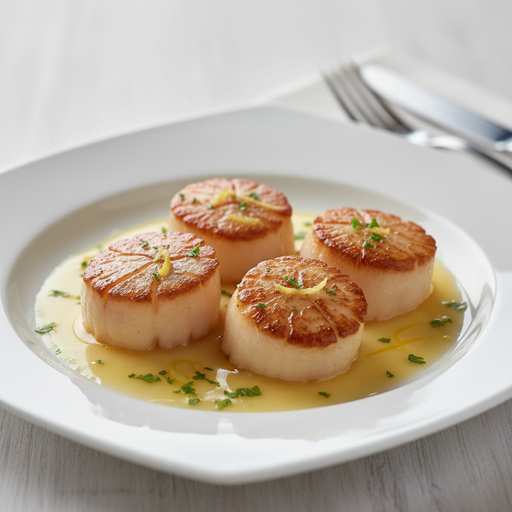

In [135]:
print(result["recipe_title"])
print()

print(result["key_ingredients"])
print()


print(result["cooking_method"])
print()
print(result["basic_preparation_steps"])
print()

print(result["image"].size if result["image"] else None)
print(result["recipe_text"])
print()

if result["image"] is not None:
    display(result["image"])

# Encore un ajustement sur manuel_baranyi_parameters et manual_arrhenius_parameters

In [ ]:
# On récupère les paramètres à modifier (modèle primaire)
import pandas as pd
df_manual_baranyi = pd.read_csv('manual_baranyi_parameters.csv', sep='\t')
df_manual_baranyi

,MatrixID,OrganismID,Temperature,Initial Value,Lag,Maximum Rate,Final Value
0,beef,ec,4.0,0.0,120.0,0.015,9.0
1,beef,ec,6.0,0.0,90.0,0.020,9.0
2,beef,ec,10.0,0.0,40.0,0.056,9.0
3,beef,ec,20.0,0.0,8.0,0.155,9.0
4,beef,ec,37.0,0.0,2.0,0.350,9.0
...,...,...,...,...,...,...,...
75,seafood,ta,4.0,0.0,30.0,0.077,9.0
76,seafood,ta,6.0,0.0,16.0,0.117,9.0
77,seafood,ta,10.0,0.0,12.0,0.189,9.0
78,seafood,ta,20.0,0.0,4.0,0.220,9.0


In [ ]:
#On réduit les colonnes Lag et Maximum Rate d'un facteur qui dépend de Temperature (voir le dictionnaire qui fait la conversion)
import pandas as pd

# dictionnaire de réduction
reductions = {
    4: 0.9,
    6: 0.8,
    10: 0.7,
    20: 0.6,
    37: 0.5
}

# copie du dataframe
corrected_df = df_manual_baranyi.copy()

# facteur de correction basé sur la température
factor = corrected_df["Temperature"].map(reductions)

# application aux colonnes
corrected_df["Lag"] = corrected_df["Lag"] * factor
corrected_df["Maximum Rate"] = corrected_df["Maximum Rate"] * factor

In [32]:
# On met initial Value à une valeur très faible sinon le fit du modèle d'Arrhénius est tout perdu
corrected_df['Initial Value'] = 1e-10

In [33]:
corrected_df.describe()

,Temperature,Initial Value,Lag,Maximum Rate,Final Value
count,80.000000,8.000000e+01,80.000000,80.000000,80.0
mean,15.400000,1.000000e-10,35.605000,0.079359,9.0
std,12.202511,0.000000e+00,36.915713,0.053267,0.0
min,4.000000,1.000000e-10,0.500000,0.009000,9.0
25%,6.000000,1.000000e-10,4.000000,0.035000,9.0
50%,10.000000,1.000000e-10,21.000000,0.070000,9.0
75%,20.000000,1.000000e-10,68.175000,0.113850,9.0
max,37.000000,1.000000e-10,126.000000,0.225000,9.0


In [34]:
arrhenius_rows, warning_rows, bad_rows = get_secondary_model_parameters(corrected_df, slice_cols=['OrganismID', 'MatrixID'], params_cols=['Initial Value', 'Lag', 'Maximum Rate', 'Final Value'] )

Fitting Arrhenius secondary models (per ['OrganismID', 'MatrixID']):   0%|          | 0/16 [00:00<?, ?slice/s]

Fitting Arrhenius secondary models (per ['OrganismID', 'MatrixID']): 100%|██████████| 16/16 [00:00<00:00, 374.20slice/s]


In [35]:
arrhenius_rows

,OrganismID,MatrixID,Initial Value,Lag,Maximum Rate,Final Value
0,ec,beef,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 4.987525290691808e-18, 'Ea': -102056.551...","{'A': 562235888.8633982, 'Ea': 55821.150265502...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
1,lm,beef,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 4.878131730644549e-15, 'Ea': -85470.3969...","{'A': 46925.77626066847, 'Ea': 32730.711344799...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
2,ss,beef,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 1.539451198357897e-14, 'Ea': -83783.9874...","{'A': 75110341.67235959, 'Ea': 51815.917075542...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
3,ta,beef,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 3.7504935918810624e-14, 'Ea': -80335.922...","{'A': 16892.67830448267, 'Ea': 29024.024594412...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
4,ec,pork,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 5.970966534922527e-12, 'Ea': -69561.8418...","{'A': 17495514.83425511, 'Ea': 47453.823678479...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
5,lm,pork,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 1.0298263536952943e-15, 'Ea': -88174.008...","{'A': 22.208927297827902, 'Ea': 12822.62609013...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
6,ss,pork,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 8.067899418343936e-17, 'Ea': -95871.6851...","{'A': 3128837488.198944, 'Ea': 60517.113124986...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
7,ta,pork,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 1.2468292351394252e-13, 'Ea': -77276.656...","{'A': 9597.92340515985, 'Ea': 27377.8793652437...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
8,ec,poultry,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 4.473307104462804e-12, 'Ea': -70193.5310...","{'A': 1743307.7004119651, 'Ea': 42477.83147585...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."
9,lm,poultry,"{'A': 9.99999999999996e-11, 'Ea': -1.595865152...","{'A': 1.867237475663614e-10, 'Ea': -60697.1167...","{'A': 26.93586614388886, 'Ea': 14111.514032930...","{'A': 8.999999999999973, 'Ea': -7.804304456526..."


In [38]:
warning_rows
bad_rows

""


In [40]:
# On sauvegarde
arrhenius_rows.to_csv('manual_arrhenius_reduced.csv', sep='\t')